# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Откройте-файл-с-данными-и-изучите-общую-информацию" data-toc-modified-id="Откройте-файл-с-данными-и-изучите-общую-информацию-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Откройте файл с данными и изучите общую информацию</a></span></li><li><span><a href="#Выполните-предобработку-данных" data-toc-modified-id="Выполните-предобработку-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Выполните предобработку данных</a></span><ul class="toc-item"><li><span><a href="#Обработка-дублитаков" data-toc-modified-id="Обработка-дублитаков-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Обработка дублитаков</a></span></li><li><span><a href="#Обработка-и-заполнение-пропусков" data-toc-modified-id="Обработка-и-заполнение-пропусков-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Обработка и заполнение пропусков</a></span><ul class="toc-item"><li><span><a href="#locality_name" data-toc-modified-id="locality_name-2.2.1"><span class="toc-item-num">2.2.1&nbsp;&nbsp;</span>locality_name</a></span></li><li><span><a href="#floors_total" data-toc-modified-id="floors_total-2.2.2"><span class="toc-item-num">2.2.2&nbsp;&nbsp;</span>floors_total</a></span></li><li><span><a href="#is_apartment" data-toc-modified-id="is_apartment-2.2.3"><span class="toc-item-num">2.2.3&nbsp;&nbsp;</span>is_apartment</a></span></li><li><span><a href="#living_area-и-kitchen_area" data-toc-modified-id="living_area-и-kitchen_area-2.2.4"><span class="toc-item-num">2.2.4&nbsp;&nbsp;</span>living_area и kitchen_area</a></span></li><li><span><a href="#days_exposition" data-toc-modified-id="days_exposition-2.2.5"><span class="toc-item-num">2.2.5&nbsp;&nbsp;</span>days_exposition</a></span></li><li><span><a href="#ceiling_height" data-toc-modified-id="ceiling_height-2.2.6"><span class="toc-item-num">2.2.6&nbsp;&nbsp;</span>ceiling_height</a></span></li><li><span><a href="#city_centers_nearest,-airports_nearest" data-toc-modified-id="city_centers_nearest,-airports_nearest-2.2.7"><span class="toc-item-num">2.2.7&nbsp;&nbsp;</span>city_centers_nearest, airports_nearest</a></span></li><li><span><a href="#ponds_nearest,-parks_nearest,-parks_around3000,-ponds_around3000" data-toc-modified-id="ponds_nearest,-parks_nearest,-parks_around3000,-ponds_around3000-2.2.8"><span class="toc-item-num">2.2.8&nbsp;&nbsp;</span>ponds_nearest, parks_nearest, parks_around3000, ponds_around3000</a></span></li></ul></li><li><span><a href="#Типы-данных" data-toc-modified-id="Типы-данных-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Типы данных</a></span><ul class="toc-item"><li><span><a href="#floors_total,-balcony,-days_exposition,-parks_around3000,-ponds_around3000" data-toc-modified-id="floors_total,-balcony,-days_exposition,-parks_around3000,-ponds_around3000-2.3.1"><span class="toc-item-num">2.3.1&nbsp;&nbsp;</span>floors_total, balcony, days_exposition, parks_around3000, ponds_around3000</a></span></li><li><span><a href="#first_day_exposition" data-toc-modified-id="first_day_exposition-2.3.2"><span class="toc-item-num">2.3.2&nbsp;&nbsp;</span>first_day_exposition</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Добавьте-в-таблицу-новые-столбцы" data-toc-modified-id="Добавьте-в-таблицу-новые-столбцы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Добавьте в таблицу новые столбцы</a></span></li><li><span><a href="#Проведите-исследовательский-анализ-данных" data-toc-modified-id="Проведите-исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Проведите исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Параметры-объектов-и-аномальные-значения" data-toc-modified-id="Параметры-объектов-и-аномальные-значения-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Параметры объектов и аномальные значения</a></span><ul class="toc-item"><li><span><a href="#Общая-площадь" data-toc-modified-id="Общая-площадь-4.1.1"><span class="toc-item-num">4.1.1&nbsp;&nbsp;</span>Общая площадь</a></span></li><li><span><a href="#Жилая-площадь" data-toc-modified-id="Жилая-площадь-4.1.2"><span class="toc-item-num">4.1.2&nbsp;&nbsp;</span>Жилая площадь</a></span></li><li><span><a href="#Площадь-кухни" data-toc-modified-id="Площадь-кухни-4.1.3"><span class="toc-item-num">4.1.3&nbsp;&nbsp;</span>Площадь кухни</a></span></li><li><span><a href="#Цена-объекта" data-toc-modified-id="Цена-объекта-4.1.4"><span class="toc-item-num">4.1.4&nbsp;&nbsp;</span>Цена объекта</a></span></li><li><span><a href="#Количество-комнат" data-toc-modified-id="Количество-комнат-4.1.5"><span class="toc-item-num">4.1.5&nbsp;&nbsp;</span>Количество комнат</a></span></li><li><span><a href="#Высота-потолков" data-toc-modified-id="Высота-потолков-4.1.6"><span class="toc-item-num">4.1.6&nbsp;&nbsp;</span>Высота потолков</a></span></li><li><span><a href="#Тип-этажа-квартиры-(«первый»,-«последний»,-«другой»)" data-toc-modified-id="Тип-этажа-квартиры-(«первый»,-«последний»,-«другой»)-4.1.7"><span class="toc-item-num">4.1.7&nbsp;&nbsp;</span>Тип этажа квартиры («первый», «последний», «другой»)</a></span></li><li><span><a href="#Общее-количество-этажей-в-доме" data-toc-modified-id="Общее-количество-этажей-в-доме-4.1.8"><span class="toc-item-num">4.1.8&nbsp;&nbsp;</span>Общее количество этажей в доме</a></span></li><li><span><a href="#Расстояние-до-центра-города-в-метрах" data-toc-modified-id="Расстояние-до-центра-города-в-метрах-4.1.9"><span class="toc-item-num">4.1.9&nbsp;&nbsp;</span>Расстояние до центра города в метрах</a></span></li><li><span><a href="#Расстояние-до-ближайшего-парка" data-toc-modified-id="Расстояние-до-ближайшего-парка-4.1.10"><span class="toc-item-num">4.1.10&nbsp;&nbsp;</span>Расстояние до ближайшего парка</a></span></li></ul></li><li><span><a href="#Скорость-продажи-квартир" data-toc-modified-id="Скорость-продажи-квартир-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Скорость продажи квартир</a></span></li><li><span><a href="#Факторы-влияющие-на-общую-(полную)-стоимость-объекта." data-toc-modified-id="Факторы-влияющие-на-общую-(полную)-стоимость-объекта.-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Факторы влияющие на общую (полную) стоимость объекта.</a></span><ul class="toc-item"><li><span><a href="#Площадь" data-toc-modified-id="Площадь-4.3.1"><span class="toc-item-num">4.3.1&nbsp;&nbsp;</span>Площадь</a></span></li><li><span><a href="#Количество-комнат" data-toc-modified-id="Количество-комнат-4.3.2"><span class="toc-item-num">4.3.2&nbsp;&nbsp;</span>Количество комнат</a></span></li><li><span><a href="#Этаж-квартиры" data-toc-modified-id="Этаж-квартиры-4.3.3"><span class="toc-item-num">4.3.3&nbsp;&nbsp;</span>Этаж квартиры</a></span></li><li><span><a href="#Дата-размещения-объявления-(день-недели,-месяц,-год)" data-toc-modified-id="Дата-размещения-объявления-(день-недели,-месяц,-год)-4.3.4"><span class="toc-item-num">4.3.4&nbsp;&nbsp;</span>Дата размещения объявления (день недели, месяц, год)</a></span></li></ul></li><li><span><a href="#Cредняя-цена-одного-квадратного-метра-в-10-населённых-пунктах-с-наибольшим-числом-объявлений" data-toc-modified-id="Cредняя-цена-одного-квадратного-метра-в-10-населённых-пунктах-с-наибольшим-числом-объявлений-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Cредняя цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений</a></span></li><li><span><a href="#Стоимость-квартир-в-Санкт-Петербурге" data-toc-modified-id="Стоимость-квартир-в-Санкт-Петербурге-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Стоимость квартир в Санкт-Петербурге</a></span></li><li><span><a href="#Дополнительные-наблюдения" data-toc-modified-id="Дополнительные-наблюдения-4.6"><span class="toc-item-num">4.6&nbsp;&nbsp;</span>Дополнительные наблюдения</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.7"><span class="toc-item-num">4.7&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Напишите-общий-вывод" data-toc-modified-id="Напишите-общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Напишите общий вывод</a></span></li></ul></div>

### Откройте файл с данными и изучите общую информацию

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Таблица широкая, отобразим все колонки
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

# Считаем данные из csv-файла в датафрейм и сохраните в переменную data

try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')

# Выведем первые 20 строк исходного датафрейма data
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.00,108.00,2019-03-07T00:00:00,3,2.70,16.00,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.00,16028.00,1.00,482.00,2.00,755.00,NaN
1,7,3350000.00,40.40,2018-12-04T00:00:00,1,NaN,11.00,18.60,1,NaN,False,False,11.00,2.00,посёлок Шушары,12817.00,18603.00,0.00,NaN,0.00,NaN,81.00
2,10,5196000.00,56.00,2015-08-20T00:00:00,2,NaN,5.00,34.30,4,NaN,False,False,8.30,0.00,Санкт-Петербург,21741.00,13933.00,1.00,90.00,2.00,574.00,558.00
3,0,64900000.00,159.00,2015-07-24T00:00:00,3,NaN,14.00,NaN,9,NaN,False,False,NaN,0.00,Санкт-Петербург,28098.00,6800.00,2.00,84.00,3.00,234.00,424.00
4,2,10000000.00,100.00,2018-06-19T00:00:00,2,3.03,14.00,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.00,8098.00,2.00,112.00,1.00,48.00,121.00
5,10,2890000.00,30.40,2018-09-10T00:00:00,1,NaN,12.00,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.00
6,6,3700000.00,37.30,2017-11-02T00:00:00,1,NaN,26.00,10.60,6,NaN,False,False,14.40,1.00,посёлок Парголово,52996.00,19143.00,0.00,NaN,0.00,NaN,155.00
7,5,7915000.00,71.60,2019-04-18T00:00:00,2,NaN,24.00,NaN,22,NaN,False,False,18.90,2.00,Санкт-Петербург,23982.00,11634.00,0.00,NaN,0.00,NaN,NaN
8,20,2900000.00,33.16,2018-05-23T00:00:00,1,NaN,27.00,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.00
9,18,5400000.00,61.00,2017-02-26T00:00:00,3,2.50,9.00,43.60,7,NaN,False,False,6.50,2.00,Санкт-Петербург,50898.00,15008.00,0.00,NaN,0.00,NaN,289.00


In [2]:
# Выведем основную информацию о датафрейме с помощью метода info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Датафрем содержит 23699 записи и 22 колонки с данными, среди которых:

- 14 колонок содержат пропущенные данные;
- имеются данные четырех типов: `int64`, `float64`, `bool`, `object`;
- колонки `floors_total` и `balcony` имеют тип данных `float64`, при этом количество этажей и балконов является натуральным числом;
- колонка `is_apartment` имеет тип данных `object`, хотя в описании тип данных указан тип `bool`




Для удобства сразу приведем название колонок в удобный вид: 

In [3]:
# переименуем столбец используя snake_case
data = data.rename(columns={'cityCenters_nearest' : 'city_centers_nearest'})

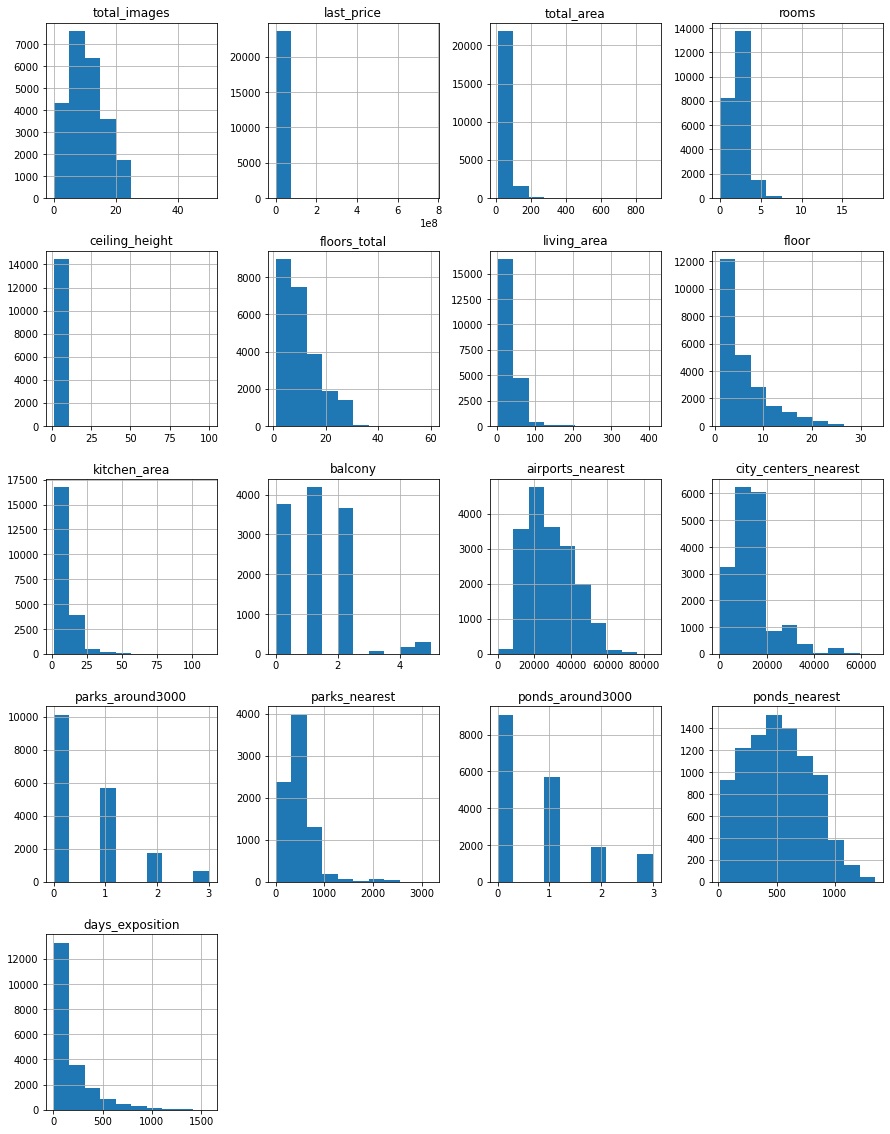

In [4]:
data.hist(figsize=(15, 20))
plt.show()

- `total_images`: объявления, как правило, содержат не более 30 фотографий, чаще всего встречаются объявления с 5-10 фотографиями
- `last_price`: график не совсем показателен, абсолютное большинство объявления попали в один столбец со стоимостью квартир 0 до 100 млрд. рублей. Наличие других корзин на оси x с нулевыми столбцами говорит о том, что объяления с большими суммами (до 800 млрд.) встречаются очень редко.
- `total_area`: в основном продаются квартиры с размерами до 300 м2, наиболее массовый сегмент - квартиры до 50 м2.
- `rooms`: в основном квартиры имеют не более 5 комнат
- `ceiling_height`: <u>значения на горизонтальной оси странные, высота потолков измеряется десятками метров</u>
- `balcony`: большинство квартир имеют 1-3 балкона, распределение результатов выглядит странным.
- `airports_nearest`: объявления близко с аэропортом (ближе 10 км) встречаются редко, что объяснимо: шум от самолетов, может нарушать покой жителей. Наиболее часто квартиры находтся на удалении около 20 км.
- `cityCenters_nearest`: большинство квартир сосредоточено в пределах 20 км от центра города, что примерно соответствует радиусу крупных городов вроде Санткт-Петербурга. При этом в центре города квартир продается меньше чем на окраине, что объяснимо, т.к. площадь к окраине увеличивается как квадрат расстояния и жилая недвижимость в основном сосредоточена в спальных районах, а не в центре. На расстоянии 20-40 км (пригород) количество объявлений существенно сокращается.
- `parks_around3000`: количество объявлений сокращается по мере роста числа парков по близости
- `parls_nearest`: <u>из графика следует, что абсолютное большинство квартир находится на удалении не более 1км от парка, что странно, т.к. данные предыдущего графика показывают, что большая часть квартир не имеет ни одного парка в радиусе 3км. Необходимо далее исследовать, в чем причина этого противоречия.</u>
- `ponds_around3000`: зависимость по водоемам такая же как и по паркам и графики выглядят похоже, можно предположить, что водоемы и парки находятся приблизительно в одних и тех же местах, что логично.
- `ponds_nearest`: <u>по графику, абсолютное большинство квартир находятся на удалении не более 1 км от водоемов, что также как и в ситуации с парками, противоречит данным с предыдущего графика.</u>
- `days_exposition`: большинство объявления как правило размещаются на период до 1.5 лет, при этом есть очень долгоживущие объявления со сроками до 5 лет. Стоит внимательней посимотреть на очень короткие и очень длинные объявления

***Вывод:***

Основываясь на предоставленной информации и подготовительном анализе данных, можно сдезаключить следующее:

- Данные представляют собой архив объявлений о продаже квартир в Санкт-Петербурге и соседних населенных пунктах.
- Каждая строка соответствует одному объявлению о продаже квартиры и содержит различные характеристики квартиры, такие как общая площадь, количество комнат, этаж, расстояние до центра, аэропорта, парков и других объектов.
- Данные собраны из двух источников - пользовательские данные, введенные вручную, и данные, автоматически полученные из картографических сервисов.
- Датафрейм содержит 23699 строк и 22 столбца, но часть значений отсутствует (содержат значение NaN), что указывает на возможные пропуски в данных.
- Присутствуют как числовые, так и категориальные переменные, что потребует соответствующей обработки для дальнейшего анализа.
- Для определения рыночной стоимости квартир необходимо будет изучить, какие параметры наиболее сильно влияют на цену объектов недвижимости.

Предварительный обзор данных позволяет сделать следующие особенности:

- Данные об объявлениях о продаже квартир содержат в основном объявления с 5-10 фотографиями, что является типичным для таких объявлений.
- График распределения цен квартир показывает, что большая часть (абсолютное большинство) объявлений относится к квартирам стоимостью до 100 млрд. рублей, при этом объявления с очень высокими ценами (до 800 млрд.) встречаются крайне редко.
- Большая часть продаваемых квартир имеют площадь до 300 кв.м., при этом наиболее массовый сегмент - квартиры до 50 кв.м.
- Квартиры, как правило, имеют не более 5 комнат.
- Данные о высоте потолков в квартирах выглядят нереалистично, вероятно, требуется дополнительная проверка этих данных.
- Распределение количества балконов в квартирах также вызывает вопросы и требует дополнительного изучения.
- Большинство квартир расположены на удалении около 20 км от ближайшего аэропорта, что, вероятно, обусловлено стремлением избежать шума от самолетов.
- Наибольшее количество квартир сосредоточено в пределах 20 км от центра города, при этом по мере удаления от центра количество объявлений возрастает.
- Количество объявлений снижается с ростом числа парков и водоемов в радиусе 3 км от квартиры, однако данные о расстоянии до ближайшего парка и водоема противоречивы и требуют дополнительного анализа.
- Большинство объявлений размещаются на период до 1.5 лет, при этом присутствуют и объявления со сроками до 5 лет, что также требует более детального изучения.


Конечная цель исследования - построить автоматизированную систему, которая сможет определять рыночную стоимость объектов недвижимости и выявлять аномалии и возможные мошеннические действия. Для этого предстоит обработать полученные данные и установить ключевые параметры, влияющие на цену квартир.

### Выполните предобработку данных

#### Обработка дублитаков

In [5]:
# проверка полных дубликатов
data.duplicated().sum()

0

Изучим уникальные значения в столбце с названиями и устраните неявные дубликаты.

In [6]:
sorted(data['locality_name'].unique().astype(str))

['nan',
 'Бокситогорск',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Высоцк',
 'Гатчина',
 'Зеленогорск',
 'Ивангород',
 'Каменногорск',
 'Кингисепп',
 'Кириши',
 'Кировск',
 'Колпино',
 'Коммунар',
 'Красное Село',
 'Кронштадт',
 'Кудрово',
 'Лодейное Поле',
 'Ломоносов',
 'Луга',
 'Любань',
 'Мурино',
 'Никольское',
 'Новая Ладога',
 'Отрадное',
 'Павловск',
 'Петергоф',
 'Пикалёво',
 'Подпорожье',
 'Приморск',
 'Приозерск',
 'Пушкин',
 'Санкт-Петербург',
 'Светогорск',
 'Сертолово',
 'Сестрорецк',
 'Сланцы',
 'Сосновый Бор',
 'Сясьстрой',
 'Тихвин',
 'Тосно',
 'Шлиссельбург',
 'городской поселок Большая Ижора',
 'городской поселок Янино-1',
 'городской посёлок Будогощь',
 'городской посёлок Виллози',
 'городской посёлок Лесогорский',
 'городской посёлок Мга',
 'городской посёлок Назия',
 'городской посёлок Новоселье',
 'городской посёлок Павлово',
 'городской посёлок Рощино',
 'городской посёлок Свирьстрой',
 'городской посёлок Советский',
 'городской посёлок Фёдоровское',
 

В списке есть косвенные дупликаты: « поселок Рябово» и «поселок городского типа Рябово», «поселок Тельмана» и «посёлок Тельмана» — это обозначения одних и тех же населённых пунктов. Уберем все вспомогательные слова "поселок", "поселок городского типа", "поселок", "посёлок" и т.д. Удалим из списка locality_names_unique все символы до первой заглавной буквы - собственного названия населенного пункта.

In [7]:
# Функция для обработки каждого значения в новой колонке
def process_locality_name(item):
    if isinstance(item, str):  # Проверяем, что значение является строкой
        index = 0
        while index < len(item) and not item[index].isupper():
            index += 1
        return item[index:]
    # в значениях есть Nan, которые распознаются как float, метод .len для них будет выдавать ошибку
    else:
        return item #поэтому добавил здесь исключение

На всякий случай скопируем исходные названия в колонку `locality_name_legacy`, а новые название перезапишем в исходной колонке `locality_name`.

In [8]:
data['locality_name_legacy'] = data['locality_name'].copy()

In [9]:
# Применение функции к значениям новой колонки с использованием метода apply
data['locality_name'] = data['locality_name'].apply(process_locality_name)

In [10]:
#проверим наличие неявных дупликатов в именах собственных населенных пунктов
sorted(data['locality_name'].unique().astype('str'))

['nan',
 'Агалатово',
 'Александровская',
 'Алексеевка',
 'Аннино',
 'Аро',
 'Барышево',
 'Батово',
 'Бегуницы',
 'Белогорка',
 'Белоостров',
 'Бокситогорск',
 'Большая Вруда',
 'Большая Ижора',
 'Большая Пустомержа',
 'Большие Колпаны',
 'Большое Рейзино',
 'Большой Сабск',
 'Бор',
 'Борисова Грива',
 'Бугры',
 'Будогощь',
 'Ваганово',
 'Важины',
 'Вартемяги',
 'Вахнова Кара',
 'Вещево',
 'Виллози',
 'Вознесенье',
 'Возрождение',
 'Войсковицы',
 'Войскорово',
 'Володарское',
 'Волосово',
 'Волхов',
 'Всеволожск',
 'Выборг',
 'Вырица',
 'Выскатка',
 'Высокоключевой',
 'Высоцк',
 'Гаврилово',
 'Гарболово',
 'Гатчина',
 'Гладкое',
 'Глажево',
 'Глебычево',
 'Глинка',
 'Гончарово',
 'Горбунки',
 'Гостилицы',
 'Громово',
 'Дзержинского',
 'Дружная Горка',
 'Дружноселье',
 'Дубровка',
 'Елизаветино',
 'Ефимовский',
 'Жилгородок',
 'Жилпосёлок',
 'Житково',
 'Заводской',
 'Заклинье',
 'Заневка',
 'Запорожское',
 'Зеленогорск',
 'Зимитицы',
 'Ивангород',
 'Извара',
 'Ильичёво',
 'Иссад',
 'Ка

Других невяных дупликатов не выявлено.

In [11]:
data.shape

(23699, 23)

#### Обработка и заполнение пропусков

In [12]:
# изучим пропущенные значения в столбцах
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
locality_name_legacy       49
dtype: int64

In [13]:
# выразим пропуски в процентном отношении к общему числу объявлений, отсротируем по возрастанию.
(
(data.isna().sum() / len(data) * 100)
    .sort_values()
)

total_images            0.00
studio                  0.00
floor                   0.00
rooms                   0.00
open_plan               0.00
total_area              0.00
last_price              0.00
first_day_exposition    0.00
locality_name_legacy    0.21
locality_name           0.21
floors_total            0.36
living_area             8.03
kitchen_area            9.61
days_exposition        13.42
ponds_around3000       23.28
parks_around3000       23.28
city_centers_nearest   23.29
airports_nearest       23.38
ceiling_height         38.80
balcony                48.61
ponds_nearest          61.56
parks_nearest          65.91
is_apartment           88.29
dtype: float64

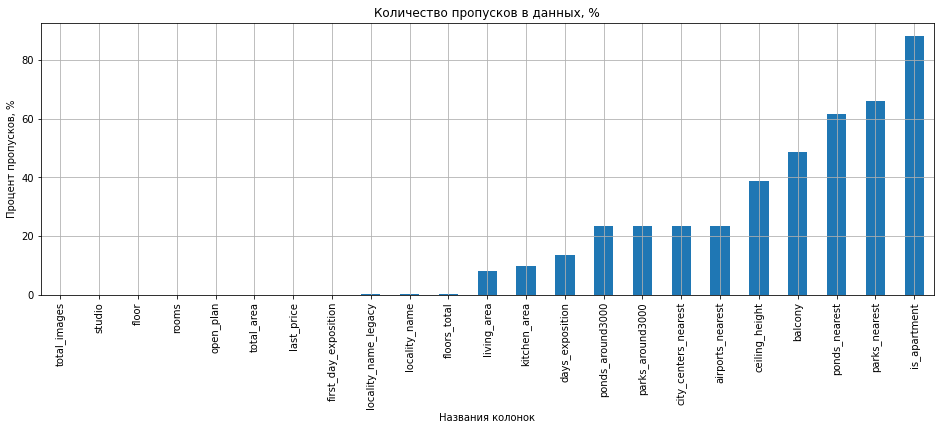

In [14]:
# Выразим пропуски по каждой колонки в виде процентного отношения к числу всех записей, отсортируем по возрастанию
(
(data.isna().sum() / len(data) * 100)
    .sort_values()
    .plot(kind='bar', figsize=(16, 5), grid=True, title='Количество пропусков в данных, %')
)

# Добавление названий xlabel и ylabel
plt.xlabel('Названия колонок')
plt.ylabel('Процент пропусков, %')

plt.show()

In [15]:
data.shape

(23699, 23)

##### locality_name

Количество пропусков в колонке `locality_name` небольшое (0,21%) от числа всех записей, но данная колонка представляется важной для дальнейшего анализа. Для однозначного задания локации квартиры достаточно две координаты, в качестве таких координат можно использовать значения дистанции до аэропорта и до центра города (т.к. центр и аэропорт у Сантк-Петербурга один, то значения буду уникальными).

In [16]:
# посмотрим расстояние до центра города и аэропорта у квартир с пропусками в locality_name
data.query('locality_name.isna()')[['airports_nearest', 'city_centers_nearest']].agg(['min', 'max'])

,airports_nearest,city_centers_nearest
min,10556.00,1322.00
max,60195.00,41294.00


In [17]:
# посмотрим какие населенные пункты имеют дистанции в пределах указанных значений
data.query('(city_centers_nearest <= 41294) and (city_centers_nearest >= 1322) and (airports_nearest >= 10556) and (airports_nearest <= 60195)')['locality_name'].unique()

array(['Санкт-Петербург', 'Шушары', 'Парголово', 'Петергоф', 'Пушкин',
       'Колпино', 'Металлострой', 'Павловск', 'Сестрорецк',
       'Красное Село', 'Понтонный', 'Стрельна', 'Александровская', nan,
       'Ломоносов', 'Песочный', 'Петро-Славянка', 'Сапёрный', 'Лисий Нос',
       'Левашово', 'Белоостров', 'Мурино', 'Усть-Ижора'], dtype=object)

In [18]:
# составим таблицу где для каждого нас. пункта из списка выше проставим мин и макс расстояния до аэропорта и города  
location_stats = (data
.groupby('locality_name')[['city_centers_nearest', 'airports_nearest']]
.agg(['min', 'max'])
.loc[['Санкт-Петербург', 'Шушары', 'Парголово', 'Петергоф', 'Пушкин',
       'Колпино', 'Металлострой', 'Павловск', 'Сестрорецк',
       'Красное Село', 'Понтонный', 'Стрельна', 'Александровская',
       'Ломоносов', 'Песочный', 'Петро-Славянка', 'Сапёрный', 'Лисий Нос',
       'Левашово', 'Белоостров', 'Мурино', 'Усть-Ижора'], :]
)
location_stats.columns = [
    'min_city',
    'max_city',
    'min_airport',
    'max_airport',
]
location_stats.head()

,min_city,max_city,min_airport,max_airport
locality_name,,,,
Санкт-Петербург,181.00,29493.00,0.00,54784.00
Шушары,17012.00,32079.00,9294.00,26293.00
Парголово,17994.00,24415.00,44346.00,61748.00
Петергоф,29815.00,49574.00,34626.00,46535.00
Пушкин,24311.00,35610.00,12157.00,21055.00


In [19]:
# Cоздадим функцию для угадывания города по мин и макс расстояниям до центра города и аэропорта из таблицы выше. 
# Если находится только одно попадание, то это и есть нужный нам город, иначе достоверно определить город не получится
def compare_location(row):
    airports_nearest = row['airports_nearest']
    city_centers_nearest = row['city_centers_nearest']
    
    matched_locations = location_stats[
        (location_stats['min_airport'] <= airports_nearest) & (location_stats['max_airport'] >= airports_nearest) &
        (location_stats['min_city'] <= city_centers_nearest) & (location_stats['max_city'] >= city_centers_nearest)
    ]
    
    if len(matched_locations) == 1:
        return matched_locations.index[0]
    else:
        return 'unknown'

In [20]:
# Применение функции compare_location к пропускам в locality_name
missing_locality_mask = data['locality_name'].isna()
data.loc[missing_locality_mask, 'locality_name'] = data[missing_locality_mask].apply(compare_location, axis=1)

In [21]:
# проверка наличия пропусков
data['locality_name'].isna().sum()

0

In [22]:
# выведем строки, по которым не удалось сделать замену
data.query('locality_name == "unknown"').head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_legacy
2033,6,5398000.00,80.00,2017-05-30T00:00:00,3,NaN,4.00,42.60,2,NaN,False,False,18.60,0.00,unknown,NaN,NaN,NaN,NaN,NaN,NaN,34.00,NaN
2603,20,3351765.00,42.70,2015-09-20T00:00:00,1,NaN,24.00,15.60,3,NaN,False,False,10.70,0.00,unknown,22041.00,17369.00,0.00,NaN,1.00,374.00,276.00,NaN
2632,2,5130593.00,62.40,2015-10-11T00:00:00,2,NaN,24.00,33.10,21,NaN,False,False,8.20,0.00,unknown,22041.00,17369.00,0.00,NaN,1.00,374.00,256.00,NaN
6765,20,4895892.00,60.70,2015-03-12T00:00:00,2,NaN,24.00,31.90,3,NaN,False,False,12.20,0.00,unknown,22041.00,17369.00,0.00,NaN,1.00,374.00,468.00,NaN
8986,10,4850000.00,103.10,2018-07-10T00:00:00,3,NaN,NaN,68.10,4,NaN,False,False,16.70,NaN,unknown,19659.00,31813.00,0.00,NaN,0.00,NaN,28.00,NaN


In [23]:
# сгруппируем по расстояниям до аэропорта и центра
data.query('locality_name == "unknown"')[['airports_nearest', 'city_centers_nearest']].value_counts()

airports_nearest  city_centers_nearest
22041.00          17369.00                8
19659.00          31813.00                1
19744.00          31897.00                1
20234.00          23659.00                1
dtype: int64

In [24]:
# Всего 4 значения, проверим есть ли еще объявления по тем же адресам вручную: 
print(data.query('(airports_nearest == 22041.0) and (city_centers_nearest == 17369.0)')['locality_name'].unique())
print(data.query('(airports_nearest == 19659.0) and (city_centers_nearest == 31813.0)')['locality_name'].unique())
print(data.query('(airports_nearest == 19744.0) and (city_centers_nearest == 31897.0)')['locality_name'].unique())
data.query('(airports_nearest == 20234.0) and (city_centers_nearest >= 23659.0)')['locality_name'].unique()

['Санкт-Петербург' 'unknown']
['unknown']
['unknown']


array(['unknown'], dtype=object)

Заменим "unknow" в доме с координатами airports_nearest = 22041.0 и city_centers_nearest >= 17369.0 на Санкт=Петербург

In [25]:
data.loc[(data['airports_nearest'] == 22041) & (data['city_centers_nearest'] == 17369), 'locality_name'] = 'Санкт-Петербург'

Все очевидные пропуски были заменены на "Санкт-Петербург". Можно предположить, что оставшиеся квартиры также находятся в Санкт-Петербурге, просто их владельцы посчитали это очевидным фактом и не заполнили соответствующие поля в анкете. 

Однако проверить догадку и однозначно определить локацию по оставшимся объектам не представляется возможным, удалим оствавшиеся строки со значениями "unknown" из датасета. 

In [26]:
# удалим строки со значениями unknown
data.drop(data[data['locality_name'] == 'unknown'].index, inplace=True)

In [27]:
data.shape

(23688, 23)

##### floors_total
Количество пропусков в колонке `floors_total` небольшое (0,36%) от числа всех записей. Вероятно, продацы не знали общее количество этажей в своих домах и поэтому оставляли поле пустым.

Заполним пропуски `floors_total` номером этажа, на котором находится квартира, из колонки `floor`, т.к. в любом случае этаж квартиры не будет превышать общее количество этажей в доме.

In [28]:
# если в колнке floors_total пропуск, заменим его на значение из колонки floor, проверим результат
data['floors_total'] = data['floors_total'].fillna(data['floor'])
data['floors_total'].value_counts()

5.00     5791
9.00     3763
16.00    1375
12.00    1368
4.00     1205
10.00    1177
25.00    1075
6.00      923
17.00     834
3.00      672
7.00      596
14.00     555
18.00     508
24.00     471
8.00      398
2.00      384
15.00     368
23.00     353
19.00     342
22.00     287
20.00     273
13.00     232
11.00     206
27.00     164
21.00     162
26.00     124
1.00       28
35.00      24
28.00      21
36.00       3
37.00       1
34.00       1
33.00       1
60.00       1
29.00       1
52.00       1
Name: floors_total, dtype: int64

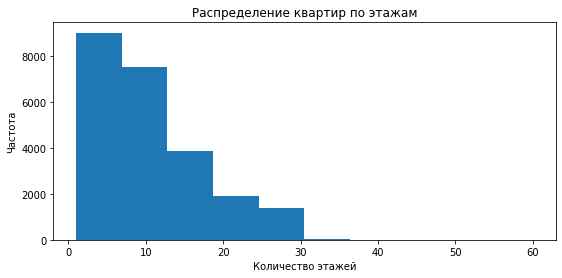

In [29]:
data['floors_total'].plot(kind='hist', figsize=(9, 4), title='Распределение квартир по этажам')
plt.xlabel('Количество этажей')
plt.ylabel('Частота')
plt.show()

In [30]:
data['floors_total'].describe()

count   23688.00
mean       10.67
std         6.60
min         1.00
25%         5.00
50%         9.00
75%        16.00
max        60.00
Name: floors_total, dtype: float64

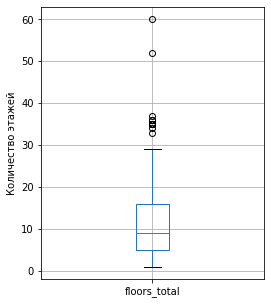

In [31]:
data.boxplot('floors_total', figsize=(4, 5))
plt.ylabel('Количество этажей')
plt.show()

На графике "ящик с усами" заметны выбросы для квартир с этажами > 17, однако это объяснимо, учитывая что в Санкт-Петербурге и окресностях присутствует высотная застройка, но таких квартир существенно меньше по сравнению с обычными многоэтажками.

##### is_apartment
Количество пропусков в колонке is_apartment огромно и составляет целых 88.29%!

Можно предположить, что данный параметр в анкете не является обязательным и большинство людей не заполнили его, т.к. не знают различий между апартаментами и квартирой. По закону квартира — это жилое помещение, а апартаменты — нежилое для временного пребывания. 

Можно предположить, что люди, которые владеют апартаментами знают об этом различии и выбирают соответствующий параметр в объявлении при продаже. Большинство же людей об этом различии не знаю и при продаже квартиры пропускают и не заполняют данный параметр.

Заполним пропуски по колонке `is_apartment` значениями False.

In [32]:
# заполним пропуски в колонке is_apartment значениями False
data['is_apartment'] = data['is_apartment'].fillna(False)

In [33]:
# проверим остались ли пропуски
data['is_apartment'].isna().sum()

0

In [34]:
data.shape

(23688, 23)

##### living_area и kitchen_area


Около 8.03% и 9.61% объявлений не имеют заполненных значений `living_area` и `kitchen_area`. При этом все объявления имеют заполенную колонку `total_area` из которой можно попытаться восстановить пропущенные значения.

Общая площадь квартиры — это сумма площадей всех частей объекта недвижимости, за исключением балконов, лоджий, веранд и террас. То есть в общую площадь входят комнаты, санузлы, кухня, кладовка, гардеробная, коридор, стены, перегородки. 

К жилой площади относятся только те помещения, которые пригодны для проживания: гостиная, спальня, детская (сюда не относятся: кухня, санузлы, коридор, кладовые и гардеробные).

Таким образом, общую площадь квартиры (`total_area`) можно представить как:

`total_area` = `living_area` + `kitchen_area` + `other_area`,

где `other_area` представляет собой все прочие нежелые помещения, перегородки и прочее. 

Узнаем в какой пропорции соотносятся составляющие общей площади квартиры в нашей выборке:

In [35]:
# соберем в переменную areas параметры объявлений, связанные с площадью
areas = data.loc[:, ['total_area', 'living_area', 'kitchen_area']]
areas.head()

,total_area,living_area,kitchen_area
0,108.00,51.00,25.00
1,40.40,18.60,11.00
2,56.00,34.30,8.30
3,159.00,NaN,NaN
4,100.00,32.00,41.00


In [36]:
# добавим в areas колонку со значением other_area
areas['other_area'] = areas['total_area'] - areas['living_area'] - areas['kitchen_area']

In [37]:
# посчитаем доли от total_area в новой таблице areas_perc
areas_perc = areas.div(areas['total_area'], axis=0).round(2)
areas_perc['total_area'] = areas['total_area']
areas_perc.head()

,total_area,living_area,kitchen_area,other_area
0,108.00,0.47,0.23,0.30
1,40.40,0.46,0.27,0.27
2,56.00,0.61,0.15,0.24
3,159.00,NaN,NaN,NaN
4,100.00,0.32,0.41,0.27


In [38]:
# посмотрим статистику по таблице areas_perc
areas_perc.describe()

,total_area,living_area,kitchen_area,other_area
count,23688.00,21787.00,21413.00,20974.00
mean,60.34,0.56,0.19,0.25
std,35.66,0.11,0.07,0.07
min,12.00,0.02,0.03,-0.58
25%,40.00,0.50,0.13,0.21
50%,52.00,0.57,0.17,0.25
75%,69.80,0.64,0.23,0.29
max,900.00,1.00,0.79,0.86


В таблице выше мы получили следующие значения средней / медианной доли составляющих вместе общую площадь квартиры:

- жилая площадь: 56.5% / 57%
- площадь кухни: 18.5% / 17%
- другая площадь: 25% / 25%

Заметим, что в колонке `other_area` присутствуют отрицательные значения. Это может означать, что жилая площадь и кухня вместе составляют больше чем общая площадь квартиры, чего не может быть на самом деле. Возможно сказывается погрешность при заполнении анкеты на сайте (при небольших отклонениях) или кто-то включил кухню в жилую площадь квартиры (полностью или частично). 

In [39]:
# выведем первые 10 отрицательных значений из колонк other_area, отсортированные по возрастанию
areas_perc.query('other_area < 0').sort_values(by='other_area').head(10)

,total_area,living_area,kitchen_area,other_area
11579,33.00,0.79,0.79,-0.58
1407,24.60,0.73,0.74,-0.47
7755,20.67,0.72,0.72,-0.45
4366,47.70,0.83,0.59,-0.43
12530,39.03,0.95,0.48,-0.42
11313,37.00,0.95,0.43,-0.38
696,34.69,0.68,0.68,-0.35
7239,90.00,0.85,0.48,-0.33
6802,69.00,0.93,0.36,-0.29
551,31.59,0.97,0.29,-0.26


In [40]:
# посчитаем количество отрицательных значений other_area
print('Количество квартир с отрицательной "other_area":', areas_perc.query('other_area < 0')['other_area'].count())

'Количество квартир с отрицательной "other_area" в процентах: {:.2f}%'.format(areas_perc.query('other_area < 0')['other_area'].count() / len(areas_perc)*100)

Количество квартир с отрицательной "other_area": 62


'Количество квартир с отрицательной "other_area" в процентах: 0.26%'

Отрицательных значений немного (всего 62 шт.), обработаем их при необходимости на более позднем этапе, а сейчас нужно решить, что делать с пропусками. Добавим в таблицу количество комнат и посмотрим, влияет ли количество комнат на имеющиеся пропорции

In [41]:
# добавим в таблицу столбец с количеством комнат
areas_perc_room = areas_perc.join(data['rooms'])
areas_perc_room.pivot_table(index='rooms', values=['living_area', 'kitchen_area', 'other_area'], aggfunc='median').describe()

,kitchen_area,living_area,other_area
count,16.00,17.00,16.00
mean,0.11,0.64,0.25
std,0.05,0.07,0.06
min,0.05,0.46,0.14
25%,0.08,0.63,0.22
50%,0.11,0.66,0.23
75%,0.12,0.69,0.27
max,0.25,0.71,0.42


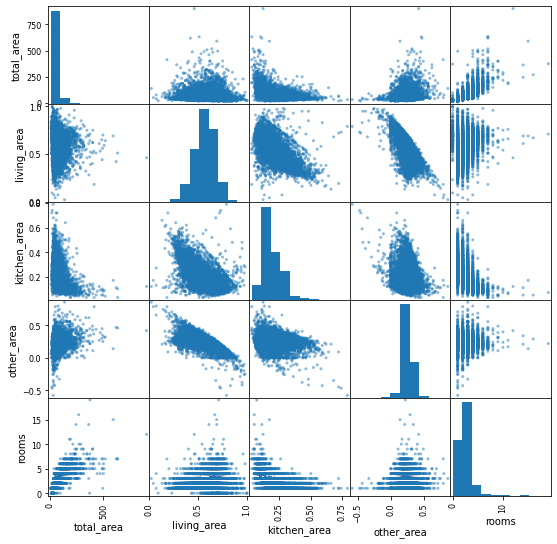

In [42]:
pd.plotting.scatter_matrix(areas_perc_room, figsize=(9,9))
plt.show()

Посмотрим на графики из первой строки матрицы рассеивания:
- на втором графике видно, что доля `living_area` не зависит от `total_area` и представляет собой нормальное распределение.
- на третьем графике заметно, что `kitchen_area` у квартир с большой площадью стремится к левому краю графика. Это значит, что у квартир с большей площадью, доля кухни в общей площади может быть меньше, чем у квартир с малой площадью, что логично.
- на четвертом графике, также не наблюдается явной зависимости `other_area` от `total_area`.

В связи с этим, можно предположить, что доли `living_area` и `other_area` в квартире практически не зависят от `total_area` и остаются приблизительно одинаковыми для квартир с любой площадью.



In [43]:
# выводы выше, подтверждаются значениями коэффициента Пирсона из таблицы корреляции ниже.
areas_perc.corr()

,total_area,living_area,kitchen_area,other_area
total_area,1.00,0.14,-0.32,0.09
living_area,0.14,1.00,-0.72,-0.71
kitchen_area,-0.32,-0.72,1.00,0.03
other_area,0.09,-0.71,0.03,1.00


Заметим также, что все квартиры-студии, квартиры с открытой планировкой и квартиры с нулевым количеством комнат, имеют значение площади кухни также равное 0. Это логично, т.к. пользователь сайта при заполнении объявления по такой квартире скорей всего не знал какую площадь кухни ему указать.

In [44]:
# выберем квартиры с открытой планировкой, студии или с 0 комнат. Посмотрим статистику по площадям в этих квартирах
data.query('((open_plan == True) or (studio == True) or (rooms == 0))')[['kitchen_area', 'living_area', 'total_area']].describe()

,kitchen_area,living_area,total_area
count,0.00,201.00,216.00
mean,NaN,19.48,30.64
std,NaN,7.82,26.83
min,NaN,2.00,15.50
25%,NaN,16.00,24.18
50%,NaN,18.00,26.59
75%,NaN,20.00,29.00
max,NaN,71.30,371.00


In [45]:
# выберем квартиры с открытой планировкой, студии или с 0 комнат. Посмотрим статистику по площадям в этих квартирах
data.query('(rooms == 1)')[['kitchen_area', 'living_area', 'total_area']].describe()

,kitchen_area,living_area,total_area
count,7212.00,7386.00,8045.00
mean,9.55,17.89,37.64
std,3.31,3.45,9.34
min,1.30,3.00,12.00
25%,7.20,16.00,32.50
50%,9.02,17.60,36.56
75%,11.00,19.00,41.00
max,58.40,60.00,494.10


Из статистики видно, что медианная доля площади кухни в квартирах студиях, квартирах с открытой планировкой или квартирах с 0 комнат, равна 9.04%, в то время как по всей выборке она составляла 17%.

In [46]:
#Посмотрим, что будет, если разбить все квартиры на 10 децилей в зависимости от их общей площади
areas_perc_room['total_area_cat'] = pd.qcut(areas_perc_room['total_area'], 30)

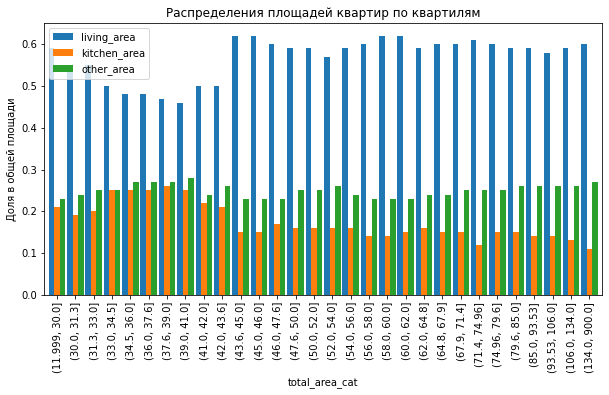

In [47]:
# построим гистограмму распределения площадей квартир по квартилям
areas_perc_room.groupby('total_area_cat')[['living_area', 'kitchen_area', 'other_area']].median().plot(kind='bar', width=0.9, figsize=(10,5))
plt.title('Распределения площадей квартир по квартилям')
plt.ylabel('Доля в общей площади')
plt.show()

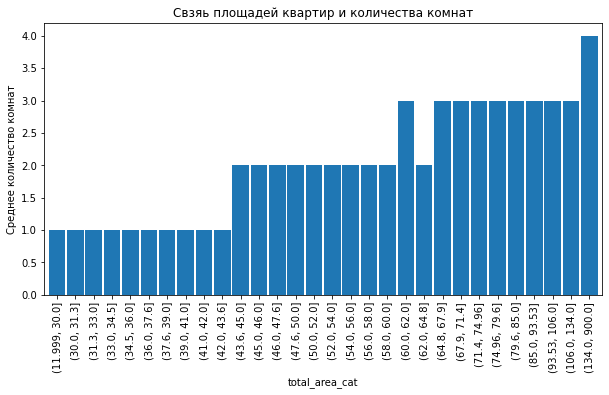

In [48]:
# построим гистограмму распределения квартир по среднему количеству комнат
areas_perc_room.groupby('total_area_cat')['rooms'].median().plot(kind='bar', width=0.9, figsize=(10,5))
plt.title('Свзяь площадей квартир и количества комнат')
plt.ylabel('Среднее количество комнат')
plt.show()

На гистограммах видно, что `other_area` всегда остается примерно на одном и том же уровне (~25%) вне зависимости от площади квартиры, в то время как остальная площадь распределяется между жилой площадью и площадью квартиры. При этом для квартир с площадью <40 м2, существует обратная зависимость между жилой площадью и площадью кухни, а для квартир >40м2 эти пропорции сохраняются примерно одинаковыми. Квартиры с площадью <40м это в основном квартиры с одной комнатой.

In [49]:
# медианные значения площадей для квартир с <= 1 комнатой
areas_perc_room.query('rooms <= 1')[['living_area', 'kitchen_area', 'other_area']].median()

living_area    0.48
kitchen_area   0.25
other_area     0.27
dtype: float64

In [50]:
# медианные значения площадей для квартир с > 1 комнатой
areas_perc_room.query('rooms > 1')[['living_area', 'kitchen_area', 'other_area']].median()

living_area    0.61
kitchen_area   0.15
other_area     0.24
dtype: float64

Заполним пропуски в колонках `living_area` и `kitchen_area` следующим образом:

- для квартир с 1 комнатой или менее, заполним пропущенные значения `living_area` и `kitchen_area` медианой по квартирам с <=1 комнатами
- для квартир с более чем однйо комнатой, заполним пропущенные значения `living_area` и `kitchen_area` медианой по квартирам с >1 комнатами

In [51]:
# заполним пропуски living_area
data.loc[(data['rooms'] <= 1) & data['living_area'].isna(),'living_area'] = data.query('rooms <= 1')['living_area'].median()
data.loc[(data['rooms'] > 1) & data['living_area'].isna(),'living_area'] = data.query('rooms > 1')['living_area'].median()

# заполним пропуски kitchen_area
data.loc[(data['rooms'] <= 1) & data['kitchen_area'].isna(),'kitchen_area'] = data.query('rooms <= 1')['kitchen_area'].median()
data.loc[(data['rooms'] > 1) & data['kitchen_area'].isna(),'kitchen_area'] = data.query('rooms > 1')['kitchen_area'].median()

In [52]:
# проверим наличие пропусков
data[['kitchen_area', 'living_area']].isna().sum()

kitchen_area    0
living_area     0
dtype: int64

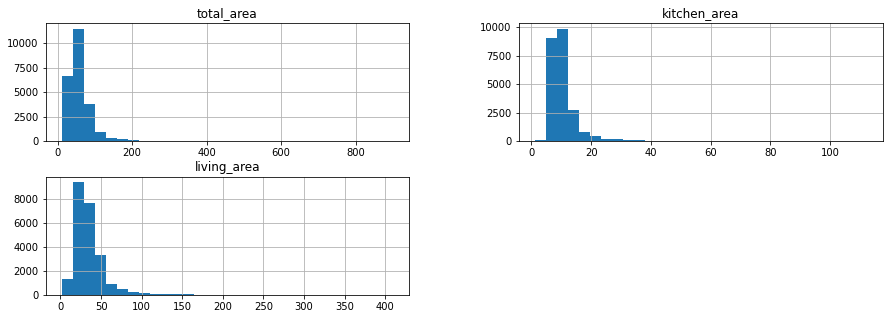

In [53]:
data[['total_area', 'kitchen_area', 'living_area']].hist(bins=30, figsize=(15, 5))
plt.show()

In [54]:
data.shape

(23688, 23)

##### days_exposition

Достаточно важный параметр, который показывает сколько дней было размещено объявление (от публикации до снятия). Если значение days_exposition было пропущено, то возможно, такая сделка еще не была закрыта или была закрыта автоматически системой, а не пользователем. Достоверно восстановить срок по другим данным не представляется возможным, заполнение медианой или средним также не подходит. Оставим пропуски как есть

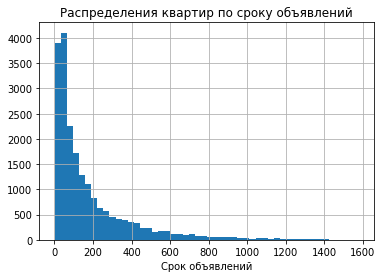

In [55]:
data.hist('days_exposition', bins=50)
plt.title('Распределения квартир по сроку объявлений')
plt.xlabel('Срок объявлений')
plt.show()

In [56]:
data.shape

(23688, 23)

In [57]:
# заменим пропуски в balcony
data['balcony'] = data['balcony'].fillna(0)

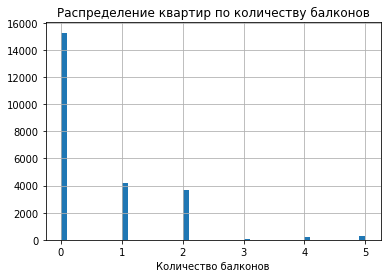

In [58]:
data.hist('balcony', bins=50)
plt.title('Распределение квартир по количеству балконов')
plt.xlabel('Количество балконов')
plt.show()

In [59]:
data.shape

(23688, 23)

##### ceiling_height

Около 38.8% объявлений не содержит информации о высоте потолков. Эта графа заполняется пользователем вручную, вероятно пользователи не знали высоту потолка, не считали ее важным параметром влиящим на цену и поэтому не заполняли.

In [60]:
# посмотрим на уникальные значения в колонке ceiling_height, отсортируем по возрастанию
sorted(data['ceiling_height'].unique())

[1.0,
 2.0,
 2.3,
 2.4,
 2.45,
 2.46,
 2.48,
 2.53,
 2.59,
 2.62,
 2.63,
 2.7,
 nan,
 1.2,
 1.75,
 2.2,
 2.25,
 2.34,
 2.47,
 2.49,
 2.5,
 2.51,
 2.52,
 2.54,
 2.55,
 2.56,
 2.57,
 2.58,
 2.6,
 2.61,
 2.64,
 2.65,
 2.66,
 2.67,
 2.68,
 2.69,
 2.71,
 2.72,
 2.73,
 2.74,
 2.75,
 2.76,
 2.77,
 2.78,
 2.79,
 2.8,
 2.81,
 2.82,
 2.83,
 2.84,
 2.85,
 2.86,
 2.87,
 2.88,
 2.89,
 2.9,
 2.91,
 2.92,
 2.93,
 2.94,
 2.95,
 2.96,
 2.97,
 2.98,
 2.99,
 3.0,
 3.01,
 3.02,
 3.03,
 3.04,
 3.05,
 3.06,
 3.07,
 3.08,
 3.09,
 3.1,
 3.11,
 3.12,
 3.13,
 3.14,
 3.15,
 3.16,
 3.17,
 3.18,
 3.2,
 3.21,
 3.22,
 3.23,
 3.24,
 3.25,
 3.26,
 3.27,
 3.28,
 3.29,
 3.3,
 3.31,
 3.32,
 3.33,
 3.34,
 3.35,
 3.36,
 3.37,
 3.38,
 3.39,
 3.4,
 3.42,
 3.43,
 3.44,
 3.45,
 3.46,
 3.47,
 3.48,
 3.49,
 3.5,
 3.51,
 3.52,
 3.53,
 3.54,
 3.55,
 3.56,
 3.57,
 3.58,
 3.59,
 3.6,
 3.62,
 3.63,
 3.65,
 3.66,
 3.67,
 3.68,
 3.69,
 3.7,
 3.75,
 3.76,
 3.78,
 3.8,
 3.82,
 3.83,
 3.84,
 3.85,
 3.86,
 3.87,
 3.88,
 3.9,
 3.93,
 3.95,


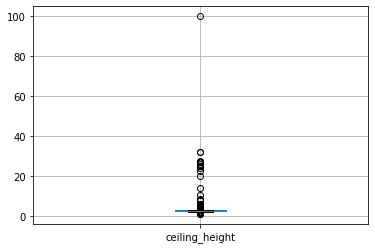

In [61]:
data.boxplot('ceiling_height')
plt.show()

В данных содерждится некоторое количество аномальных значений:
- для некоторых квартир указана высота потолков 25 м и 32 м. Логично предположить, что на самом деле это вещественные значения: 2.5 м и 3.2 м. Разделим указанные значения на 10.
- в выборке также есть квартиры с аномальной высотой полотка ниже 2.5м (нарушение требования к жилым помещениям) и выше 10 метров (маловероятно что существуют квартиры такой высоты, даже если в них несколько этаже или это частный дом). 

Вероятная причина ошибки - человеческий фактор.

In [62]:
# Замена значений в диапазоне от 25 до 32
data['ceiling_height'] = data['ceiling_height'].where(~((data['ceiling_height'] >= 25) & (data['ceiling_height'] <= 32)), data['ceiling_height'] / 10)

In [63]:
# найдем долю значений ниже 2.5 и выше 10м в общей выборке
len(data.query('((ceiling_height > 10) or (ceiling_height < 2.5))')) / len(data)

0.0033350219520432286

После замены, строк с аномальными значениям ceiling_height осталось менее 0.5%. Удалим их, т.к. данные по высоте помещений в них заполненные некорректно

In [64]:
# удалим комнаты с высотой потолков <2.5 и >10 м
data.drop(data[(data['ceiling_height'] < 2.5) | (data['ceiling_height'] > 10)].index, inplace=True)
data.reset_index(drop=True, inplace=True)

In [65]:
# Посмотрим разброс данных по получившемуся массиву
data['ceiling_height'].describe()

count   14422.00
mean        2.73
std         0.29
min         2.50
25%         2.52
50%         2.65
75%         2.80
max         8.30
Name: ceiling_height, dtype: float64

Разброс квартир по высоте потолка небольшой, поэтому заменим данные по всем оставшимся пропускам медианным значением

In [66]:
data['ceiling_height'].fillna(data['ceiling_height'].median(), inplace=True)
data['ceiling_height'].isna().sum()

0

In [67]:
data.shape

(23609, 23)

##### city_centers_nearest, airports_nearest

Пропусков в полях 'city_centers_nearest', 'airports_nearest', 'parks_around3000', 'ponds_around3000' практически одинаковое количество, возможно между ними есть связь, рассмотрим поближе.

In [68]:
data[['city_centers_nearest', 'airports_nearest', 'parks_around3000', 'ponds_around3000']].isna().sum()

city_centers_nearest    5480
airports_nearest        5503
parks_around3000        5479
ponds_around3000        5479
dtype: int64

Данные поля заполняются системой автоматически на основании адреса введенного пользователем. Видно, что количество пропусков по всем четырем полям примерно одинаковое. Скорей всего алгоритм не смог распознать адрес (пользователем допущена ошибка или опечатка) или в работе алгоритма есть техничеcкая ошибка.

In [69]:
# пропуски parks_around3000 и ponds_around3000 полностью совпадают
len(data.query('parks_around3000.isna() and ponds_around3000.isna()'))

5479

In [70]:
# по ним нету ни одной координаты
data.query('parks_around3000.isna() and ponds_around3000.isna()')[['airports_nearest', 'city_centers_nearest', 'parks_around3000', 'parks_nearest']].describe()

,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest
count,0.00,0.00,0.00,0.00
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


city_center_nearest не проставлен в одном объявлении, хотя расстояние до аэропорта и ближайшего парка в таблице указано. Видимо ошибка в работе алгоритма или при формировании выгрузки данных. 

In [71]:
# city_center_nearest не проставлен в одном объявлении
data.query('not parks_around3000.isna() and city_centers_nearest.isna()')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_legacy
20124,2,10500000.00,85.00,2019-01-08T00:00:00,3,3.00,3.00,55.50,2,False,False,False,8.00,1.00,Пушкин,15527.00,NaN,1.00,134.00,0.00,NaN,NaN,Пушкин


airport_nearest не проставлен в 24 строках, хотя по ним есть другие расстояния. Видимо такая же ошибка в ситуации с city_center_nearest выше

In [72]:
# airport_nearest не проставлен в 24 строках, все они в Санкт-Петербурге
print(len(data.query('not parks_around3000.isna() and airports_nearest.isna()')['locality_name']))
data.query('not parks_around3000.isna() and airports_nearest.isna()')['locality_name'].unique()

24


array(['Санкт-Петербург'], dtype=object)

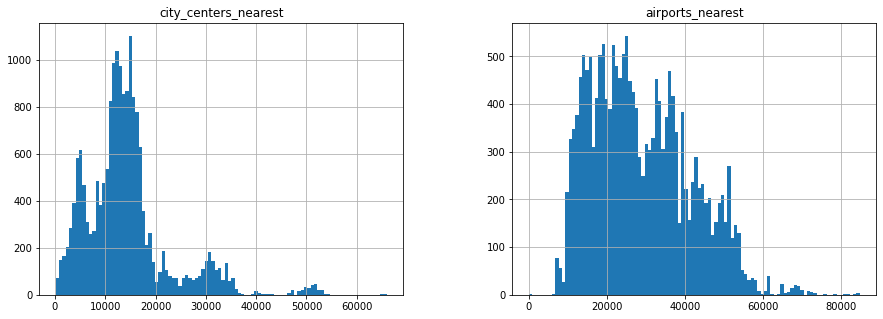

In [73]:
# оценим корректности произведенной замены на гистограмме
data[['city_centers_nearest', 'airports_nearest']].hist(bins=100, figsize=(15, 5))
plt.show()

Пропуски расстояний по центра города и аэропорта представляют собой случайные величины, поэтому выявить закономерность, которая поможет заполнить пропуски, не представляется возможным.

Заполнение пропусков медианой, средним или другим значением (например, совокупно или в разрезе по городам) искажает данные и вносит искусственные пики в распределение.

Поэтому оставим пропуски как есть

In [74]:
data[['city_centers_nearest', 'airports_nearest']].isna().sum()

city_centers_nearest    5480
airports_nearest        5503
dtype: int64

In [75]:
data.shape

(23609, 23)

##### ponds_nearest, parks_nearest, parks_around3000, ponds_around3000

In [76]:
data[['ponds_nearest', 'parks_nearest', 'parks_around3000', 'ponds_around3000']].isna().sum()

ponds_nearest       14525
parks_nearest       15560
parks_around3000     5479
ponds_around3000     5479
dtype: int64

Заметим, что пропусков по дистанции до ближайшего парка/водоема существенно больше, чем по наличию парка/водоема в округе. Посмотрим, сколько парков/прудов в округе имеют квартиры с отсутствующей информации о дистанции до соответствующих объектов и какие значения они принимают.

In [77]:
# заполненое поле ponds_around3000 и незаполненное ponds_nearest
data.query('ponds_nearest.isna() and not ponds_around3000.isna()')['ponds_around3000'].value_counts()

0.00    9046
Name: ponds_around3000, dtype: int64

In [78]:
# заполненое поле parks_around3000 и незаполненное parks_nearest
data.query('parks_nearest.isna() and not parks_around3000.isna()')['parks_around3000'].value_counts()

0.00    10081
Name: parks_around3000, dtype: int64

Количество прудов или парков по данным объектам с отсутствующей дистанцией автоматически проставилось 0. Однако, интересно то, что не всем квартирам с отсутствующими дистанциями до ближайших объектов было автоматически проставлено значение 0 в колонках `parks_around3000` и `ponds_around3000`. Это указывает на то, что причина пропусков может быть связана не только с ошибками в адресах объектов, которые заполнили пользователи, но и с работой алгоритма. 

При этом пропуски значений в `ponds_around3000` и `parks_around3000`, как-то связано с пропусками по `city_centers_nearest` и `airports_nearest`, так как их число практически совпадает. Вероятно, там где есть пропуски по всем 4 дистанциям, адрес был некорректно введен пользователем.

По остальным объектам, в базе есть информация о расстояниях до центра города и до аэропорта, значит адрес объект был указан верно и известен системе. Возможно, радиус поиска ближайших парков/водоемов ограничен алгоритмом с целью экономии ресурсов. Посмотрим, на min и max расстояния до объектов, которые он в результате нашел:

In [79]:
data[['parks_nearest', 'ponds_nearest']].describe()

,parks_nearest,ponds_nearest
count,8049.00,9084.00
mean,490.83,518.10
std,342.79,277.75
min,1.00,13.00
25%,288.00,294.00
50%,454.00,503.00
75%,612.00,730.00
max,3190.00,1344.00


Видим, что самый дальний парк расположился на расстоянии 3190 метров, в самый дальний водоем - на расстоянии 1344 метра. Скорей всего радиус поиска был ограничен расстоянием немногим более 3км от объекта, а в случае если в этом радиусе ничего не находилось, алгоритм прекращал поиск и выставлял значение дистанции до ближайшего парка/водоема равное 0.

Для пропущенных значений parks_around3000, ponds_around3000 проставим значение 0, т.к. информация о наличии вблизи этих квартир водоемов или парков отсутствует.

In [80]:
data[['parks_around3000', 'ponds_around3000']] = data[['parks_around3000', 'ponds_around3000']].fillna(0)

Расстояния до ближайшего парка и водоема заменить не получится, оставим пропуски как есть

In [81]:
# проверим оставшиеся пропуски по всем столбцам
(
(data.isna().sum() / len(data) * 100)
    .sort_values()
)

total_images            0.00
ponds_around3000        0.00
parks_around3000        0.00
locality_name           0.00
balcony                 0.00
kitchen_area            0.00
studio                  0.00
is_apartment            0.00
open_plan               0.00
living_area             0.00
floors_total            0.00
ceiling_height          0.00
rooms                   0.00
first_day_exposition    0.00
total_area              0.00
last_price              0.00
floor                   0.00
locality_name_legacy    0.16
days_exposition        13.42
city_centers_nearest   23.21
airports_nearest       23.31
ponds_nearest          61.52
parks_nearest          65.91
dtype: float64

#### Типы данных

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23609 entries, 0 to 23608
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23609 non-null  int64  
 1   last_price            23609 non-null  float64
 2   total_area            23609 non-null  float64
 3   first_day_exposition  23609 non-null  object 
 4   rooms                 23609 non-null  int64  
 5   ceiling_height        23609 non-null  float64
 6   floors_total          23609 non-null  float64
 7   living_area           23609 non-null  float64
 8   floor                 23609 non-null  int64  
 9   is_apartment          23609 non-null  bool   
 10  studio                23609 non-null  bool   
 11  open_plan             23609 non-null  bool   
 12  kitchen_area          23609 non-null  float64
 13  balcony               23609 non-null  float64
 14  locality_name         23609 non-null  object 
 15  airports_nearest   

##### floors_total, balcony, days_exposition, parks_around3000, ponds_around3000

Значения колонкок `floors_total`, `balcony`, `parks_around3000`, `ponds_around3000` представляют собой натуральные числа, также преобразуем в int

In [83]:
# преобразуем в int
data[['floors_total', 'balcony', 'parks_around3000', 'ponds_around3000']] = data[['floors_total', 'balcony', 'parks_around3000', 'ponds_around3000']].astype(int)

##### first_day_exposition

In [84]:
data['first_day_exposition'].head()

0    2019-03-07T00:00:00
1    2018-12-04T00:00:00
2    2015-08-20T00:00:00
3    2015-07-24T00:00:00
4    2018-06-19T00:00:00
Name: first_day_exposition, dtype: object

Преобразуем данные в формат datetime.

In [85]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23609 entries, 0 to 23608
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23609 non-null  int64         
 1   last_price            23609 non-null  float64       
 2   total_area            23609 non-null  float64       
 3   first_day_exposition  23609 non-null  datetime64[ns]
 4   rooms                 23609 non-null  int64         
 5   ceiling_height        23609 non-null  float64       
 6   floors_total          23609 non-null  int64         
 7   living_area           23609 non-null  float64       
 8   floor                 23609 non-null  int64         
 9   is_apartment          23609 non-null  bool          
 10  studio                23609 non-null  bool          
 11  open_plan             23609 non-null  bool          
 12  kitchen_area          23609 non-null  float64       
 13  balcony         

#### Вывод

В процессе предобработки данных были выполнены следующие действия по предобработке данных:

**1. Обработка дубликатов:**
- полных дубликатов выявлено не было;
- в колонке `locality_name` содержались неявные дубликаты с разными вариациями написания одни и тех же названий населенных пунктов. Неявные дубликаты были устранены путем исключения служебных слов из названий населенных пунктов. Колонка`locality_name` была перезаписана, в ней были сохранены имена собственные населенных пунктов. Исходные данные были сохранены в отдельную колонку `locality_name_legacy`.

**2. Обработка и заполнение пропущенных значений:**

- Общее количество пропущенных значений в различных столбцах варьируется от 0 до 88.29% от общего числа записей. Наибольшее количество пропусков наблюдается в столбцах "is_apartment" (88.29%), "parks_nearest" (65.91%), "ponds_nearest" (61.56%) и "balcony" (48.61%).
- `locality_name`: была выполнена обработка пропущенных значений в колонке "locality_name" на основе расстояний до центра города и аэропорта. С помощью анализа минимальных и максимальных значений расстояний для различных населенных пунктов, была создана функция для определения города. Пропущенные значения были заменены на "Санкт-Петербург", за исключением некоторых строк, для которых невозможно достоверно определить город. Оставшиеся пропуски были удалены из выборки.
- `floors_total`: пропуски были заполнены номерами этажей из колонки "floor", предполагая, что этаж квартиры не превышает общее количество этажей в доме и количество пропусков невелико.
- `is_apartment`: 88,29% значений в этой колонке являются пропущенными. Было сделано предположение, что большинство людей не заполнили этот параметр, так как они не знают разницы между апартаментами и квартирами. Для обработки пропущенных значений в этой колонке было решено заполнить их значением False, т.к. владельцы апартаментов точно знают что у них апартаменты и указали бы это в анкете. 
- `living_area` и `kitchen_area`: 8.03% и 9.61% объявлений не содержат заполненных значений для жилой площади и площади кухни соответственно. Среди рассмотренных данных, средняя доля жилой площади составляет примерно 56.5%, доля площади кухни - около 18.5%, а другие помещения занимают примерно 25%. Однако, по ряду наблюдений, сумма жилой площади и кухни превышала общую площадь помещения, что могло быть связано с ошибками при заполнении анкеты или неправильным учётом площади кухни в жилой площади квартиры. Анализ данных о площадях жилых помещений и кухонь показал, что площадь других помещений (`other_area`) остается примерно на одном уровне (около 25%), в то время как остальная площадь распределяется между жилой площадью и площадью кухни. Для заполнения пропущенных значений в колонках `living_area` и `kitchen_area` был использован подход, основанный на медиане значений в зависимости от количества комнат: 
 - для квартир с одной комнатой или менее значения были заполнены медианой по квартирам с <=1 комнатами,
 - для квартир с более чем одной комнатой - медианой по квартирам с >1 комнатами.
- `days_exposition`: пропущенные значения можно заменить не получится, оставили пропуски как есть.
- `balcony`: пропущенные значения можно заменить на 0, предполагая, что отсутствие указания числа балконов означает их отсутствие в квартире.
- `ceiling_height`: около 38.8% объявлений не содержит информации о высоте потолков. Пропущенные значения могут быть связаны с тем, что пользователи не считали этот параметр важным. Были обнаружены аномальные значения, такие как 25 м и 32 м, которые были скорректированы на значения 2.5 м и 3.2 м соответственно. Затем были удалены строки с потолками ниже 2.5 м и выше 10 м (около 0.5% датасета). Оставшиеся пропущенные значения были заменены медианным значением.
-  `city_centers_nearest`, `airports_nearest`: около 23% датасета не содержат информацию о расстояниях до центра города и аэропорта (и вообще никакой информации о дистанциях). Пропуски могут быть связаны с ошибками пользователей при вводе адреса или технической ошибкой, связанной с работой алгоритма расчета дистанции. Пропуски за пределами Санкт-Петербурга были заменены на средние значения по тому же населенному пункту, а в случае остуствия такой информации - на средние значения по всем квартирам за пределами города. Пропуски по Санкт-Петербургу были удалены из выборки.
- `ponds_nearest`, `parks_nearest`: Количество пропусков по этим полям значительно выше (61-66%) чем количество пропусков в расстояниях до аэропорта или центра города. Возможно, радиус поиска ближайших парков/водоемов ограничен алгоритмом (в районе четь более 3 км.) с целью экономии программных ресурсов. Пропуски оставлены как есть.
- `parks_around3000`, `ponds_around3000`: пропущенные значений parks_around3000, ponds_around3000 были заполнены 0, т.к. информация о наличии вблизи этих квартир водоемов или парков отсутствует.

**3. Изменение типов данных**

- значения колонок `floors_total`, `balcony`, `parks_around3000` и `ponds_around3000` должны представлять собой натуральные числа, они были преобразованы в тип данных `int`.
- колонка `first_day_exposition` содержит даты и была преобразована в тип данных `datetime`.

### Добавьте в таблицу новые столбцы

In [87]:
# Рассчитываем цену одного квадратного метра
data['price_per_meter'] = round(data['last_price'] / data['total_area'], 2)

In [88]:
# Рассчитываем день недели публикации объявления
data['weekday'] = data['first_day_exposition'].dt.weekday

In [89]:
# Рассчитываем месяц публикации объявления
data['month'] = data['first_day_exposition'].dt.month

In [90]:
# Рассчитываем год публикации объявления
data['year'] = data['first_day_exposition'].dt.year

In [91]:
# Рассчитываем тип этажа квартиры
def get_floor_type(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

# Применяем функцию к каждой строке с помощью метода apply
data['floor_type'] = data.apply(get_floor_type, axis=1)

In [92]:
# Рассчитываем расстояние до центра города в километрах
data['city_center_nearest_km'] = round(data['city_centers_nearest'] / 1000).astype('Int64')

In [93]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_legacy,price_per_meter,weekday,month,year,floor_type,city_center_nearest_km
0,20,13000000.00,108.00,2019-03-07,3,2.70,16,51.00,8,False,False,False,25.00,0,Санкт-Петербург,18863.00,16028.00,1,482.00,2,755.00,NaN,Санкт-Петербург,120370.37,3,3,2019,другой,16
1,7,3350000.00,40.40,2018-12-04,1,2.65,11,18.60,1,False,False,False,11.00,2,Шушары,12817.00,18603.00,0,NaN,0,NaN,81.00,посёлок Шушары,82920.79,1,12,2018,первый,19
2,10,5196000.00,56.00,2015-08-20,2,2.65,5,34.30,4,False,False,False,8.30,0,Санкт-Петербург,21741.00,13933.00,1,90.00,2,574.00,558.00,Санкт-Петербург,92785.71,3,8,2015,другой,14
3,0,64900000.00,159.00,2015-07-24,3,2.65,14,38.00,9,False,False,False,9.20,0,Санкт-Петербург,28098.00,6800.00,2,84.00,3,234.00,424.00,Санкт-Петербург,408176.10,4,7,2015,другой,7
4,2,10000000.00,100.00,2018-06-19,2,3.03,14,32.00,13,False,False,False,41.00,0,Санкт-Петербург,31856.00,8098.00,2,112.00,1,48.00,121.00,Санкт-Петербург,100000.00,1,6,2018,другой,8


**Выводы:**

В таблицу были добавлены новые столбцы со следующими параметрами:
- `price_per_meter`: цена одного квадратного метра (стоимость объекта поделить на его общую площадь и округлить до двух знаков после запятой);
- `weekday`: день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
- `month`: месяц публикации объявления;
- `year`: год публикации объявления;
- `floor_type`: тип этажа квартиры (значения — «первый», «последний», «другой»);
- `city_center_nearest_km`: расстояние до центра города в километрах (округлили до ближайших целых значений).

### Проведите исследовательский анализ данных

#### Параметры объектов и аномальные значения

Частично аномальные значения были исключены на предыдущих этапах предобработки данных. Еще раз посмотрим, остались ли такие значение после первоначально обработки.

##### Общая площадь

In [94]:
# изучим статистику по колонке
data['total_area'].describe()

count   23609.00
mean       60.38
std        35.70
min        12.00
25%        40.00
50%        52.00
75%        70.00
max       900.00
Name: total_area, dtype: float64

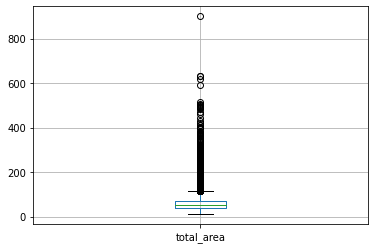

In [95]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('total_area')
plt.show()

In [96]:
# Найдем границы ящика с усами
def wiskers(column, df=data):
    # Расчет квартилей
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Расчет интерквартильного размаха (IQR)
    IQR = Q3 - Q1

    # Расчет границ ящика с усами
    lower_whisker = df[column][df[column] >= (Q1 - 1.5 * IQR)].min()
    upper_whisker = df[column][df[column] <= (Q3 + 1.5 * IQR)].max()

    return lower_whisker, upper_whisker

In [97]:
wiskers('total_area')

(12.0, 115.0)

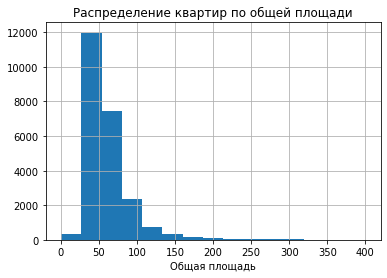

In [98]:
# построим гистограмму
data['total_area'].hist(bins=15, range=(0,400))
plt.title('Распределение квартир по общей площади')
plt.xlabel('Общая площадь')
plt.show()

Общая площадь квартир находится в диапазоне от 12 до 900 м2.
Средняя площадь: 60.25м2, медиана: 52м2.

Общая площадь большинства квартир находится в диапазона от 12 до 114.5м2, при на графике заметны выбросы значений для квартир с очень большой площадью. Но это объяснимо, т.к. в выборку могли попасть частные коттеджи или квартиры в элитных домах с большой площадью.

График имеет вид распределения Пуассона, аномалий не заметно.

##### Жилая площадь

In [99]:
# изучим статистику по колонке
data['living_area'].describe()

count   23609.00
mean       34.18
std        21.36
min         2.00
25%        18.40
50%        30.31
75%        41.10
max       409.70
Name: living_area, dtype: float64

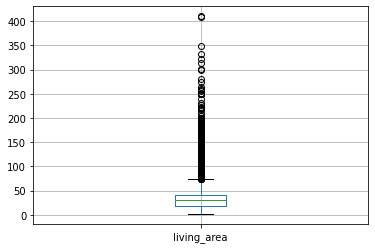

In [100]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('living_area')
plt.show()

In [101]:
wiskers('living_area')

(2.0, 75.1)

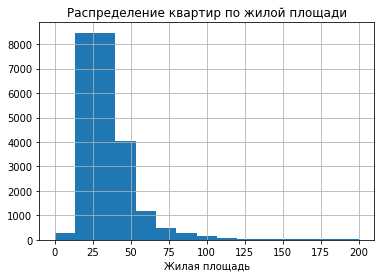

In [102]:
# построим гистограмму
data['living_area'].hist(bins=15, range=(0,200))
plt.title('Распределение квартир по жилой площади')
plt.xlabel('Жилая площадь')
plt.show()

Жилая площадь квартир находится в диапазоне от 2 до 409 м2.
Средняя площадь: 34м2, медиана: 30м2.

Жилая площадь большинства квартир находится в диапазона от 2 до 75.1м2, при на графике также заметны выбросы значений для квартир с очень большой жилой площадью. Это логично, такую же картину мы видели ранее на графике с общей площадью.

Квартиры с жилой площадью 2м2 вызывают подозрения, однако это могут быть маленькие квартиры с отдельным помещением под спальню, а остальную площадь занимает кухня или другие помещения. 

График имеет вид распределения Пуассона, других аномалий не заметно.

In [103]:
data.sort_values(by='living_area').head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_legacy,price_per_meter,weekday,month,year,floor_type,city_center_nearest_km
21681,0,2330000.00,23.00,2018-01-01,0,2.65,24,2.00,22,False,True,False,9.02,0,Мурино,NaN,NaN,0,NaN,0,NaN,66.00,посёлок Мурино,101304.35,0,1,2018,другой,<NA>
13872,20,6350000.00,52.00,2018-02-06,2,3.00,6,2.00,2,False,False,False,9.00,0,Санкт-Петербург,32453.00,6521.00,0,NaN,1,1012.00,91.00,Санкт-Петербург,122115.38,1,2,2018,другой,7
3230,7,4440000.00,41.00,2017-07-02,1,2.65,17,3.00,17,False,False,False,11.00,0,Санкт-Петербург,19272.00,13073.00,0,NaN,0,NaN,216.00,Санкт-Петербург,108292.68,6,7,2017,последний,13
23484,14,64990000.00,139.00,2015-11-24,3,3.00,8,3.00,8,False,False,False,16.00,1,Санкт-Петербург,33255.00,5975.00,1,630.00,3,100.00,280.00,Санкт-Петербург,467553.96,1,11,2015,последний,6
17524,11,2680000.00,22.00,2018-08-11,0,2.65,25,5.00,8,False,True,False,9.02,2,Санкт-Петербург,22735.00,11618.00,1,835.00,1,652.00,70.00,Санкт-Петербург,121818.18,5,8,2018,другой,12


##### Площадь кухни

In [104]:
# изучим статистику по колонке
data['kitchen_area'].describe()

count   23609.00
mean       10.44
std         5.63
min         1.30
25%         7.40
50%         9.20
75%        11.50
max       112.00
Name: kitchen_area, dtype: float64

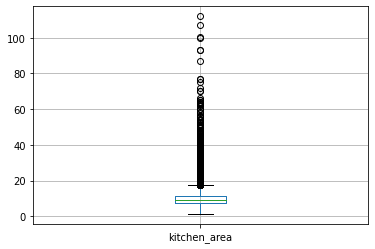

In [105]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('kitchen_area')
plt.show()

In [106]:
wiskers('kitchen_area')

(1.3, 17.64)

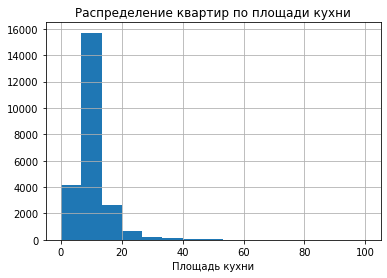

In [107]:
# построим гистограмму
data['kitchen_area'].hist(bins=15, range=(0,100))
plt.title('Распределение квартир по площади кухни')
plt.xlabel('Площадь кухни')
plt.show()

Площадь кухни квартир находится в диапазоне от 1.3 до до 112 м2. Средняя площадь: 10м2, медиана: 9м2.

Жилая площадь большинства квартир находится в диапазона от 2 до 17.4м2, при на графике также заметны выбросы значений для квартир с площадью более 17 метров. 

График имеет вид распределения Пуассона, аномалий не заметно.

##### Цена объекта

In [108]:
# изучим статистику по колонке
data['last_price'].describe()

count       23609.00
mean      6551229.53
std      10905710.53
min         12190.00
25%       3430000.00
50%       4650000.00
75%       6800000.00
max     763000000.00
Name: last_price, dtype: float64

In [109]:
data.sort_values(by='last_price')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_legacy,price_per_meter,weekday,month,year,floor_type,city_center_nearest_km
8763,7,12190.00,109.00,2019-03-20,2,2.75,25,32.00,25,False,False,False,40.50,0,Санкт-Петербург,36421.00,9176.00,1,805.00,0,NaN,8.00,Санкт-Петербург,111.83,2,3,2019,последний,9
17400,7,430000.00,30.40,2019-04-22,1,2.65,2,16.00,1,False,False,False,6.00,0,Сланцы,NaN,NaN,0,NaN,0,NaN,NaN,Сланцы,14144.74,0,4,2019,первый,<NA>
14864,5,430000.00,54.00,2018-06-26,2,2.65,3,38.00,3,False,False,False,9.20,0,Свирь,NaN,NaN,0,NaN,0,NaN,44.00,посёлок станции Свирь,7962.96,1,6,2018,последний,<NA>
16222,18,440000.00,40.00,2018-07-10,1,2.65,5,17.60,1,False,False,False,9.02,0,Старополье,NaN,NaN,0,NaN,0,NaN,45.00,деревня Старополье,11000.00,1,7,2018,первый,<NA>
16168,14,450000.00,38.50,2018-07-11,2,2.65,2,38.00,1,False,False,False,9.20,0,Вахнова Кара,NaN,NaN,0,NaN,0,NaN,45.00,деревня Вахнова Кара,11688.31,2,7,2018,первый,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15601,20,300000000.00,618.00,2017-12-18,7,3.40,7,258.00,5,False,False,False,70.00,0,Санкт-Петербург,32440.00,5297.00,0,NaN,2,198.00,111.00,Санкт-Петербург,485436.89,0,12,2017,другой,5
1429,19,330000000.00,190.00,2018-04-04,3,3.50,7,95.00,5,False,False,False,40.00,0,Санкт-Петербург,23011.00,1197.00,3,519.00,3,285.00,233.00,Санкт-Петербург,1736842.11,2,4,2018,другой,1
14659,15,401300000.00,401.00,2016-02-20,5,2.65,9,204.00,9,False,False,False,24.00,3,Санкт-Петербург,21912.00,2389.00,1,545.00,1,478.00,393.00,Санкт-Петербург,1000748.13,5,2,2016,последний,2
19476,8,420000000.00,900.00,2017-12-06,12,2.80,25,409.70,25,False,False,False,112.00,0,Санкт-Петербург,30706.00,7877.00,0,NaN,2,318.00,106.00,Санкт-Петербург,466666.67,2,12,2017,последний,8


In [110]:
# медианная стоимость квартиры площшадью 109 м2
data.query('total_area == 109')['last_price'].median()

13350000.0

Стоимость квартиры площадью 109м2 за  12190 рублей выглядит неправдоподобно. Скорей всего стоимость указана в тыс. рублей. Домножим значение на 1000.

In [111]:
data.loc[data['last_price'] == 12190.00, 'last_price'] *= 1000

In [112]:
# обновим статистику по колонке
data['last_price'].describe()

count       23609.00
mean      6551745.34
std      10905689.23
min        430000.00
25%       3430000.00
50%       4650000.00
75%       6800000.00
max     763000000.00
Name: last_price, dtype: float64

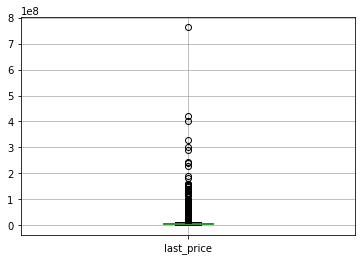

In [113]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('last_price')
plt.show()

In [114]:
wiskers('last_price')

(430000.0, 11850000.0)

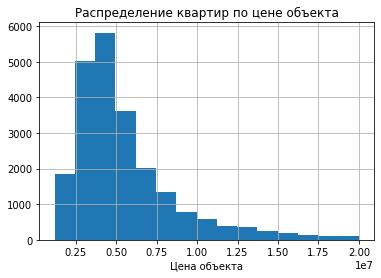

In [115]:
# построим гистограмму
data['last_price'].hist(bins=15, range=(1190000, 20000000))
plt.title('Распределение квартир по цене объекта')
plt.xlabel('Цена объекта')
plt.show()

Цены квартир находятся в диапазоне от 430 тыс.  до 763 млн. рублей. Средняя цена: 6.5 млн. рублей, медиана: 4.7 млн. рублей.

Стоимость большинства квартир находится в диапазона от 0,4 до 11.8 млн. рублей, но есть и более дорогие варианты.

График имеет вид распределения Пуассона, аномалий не заметно.

##### Количество комнат

In [116]:
# изучим статистику по колонке
data['rooms'].describe()

count   23609.00
mean        2.07
std         1.08
min         0.00
25%         1.00
50%         2.00
75%         3.00
max        19.00
Name: rooms, dtype: float64

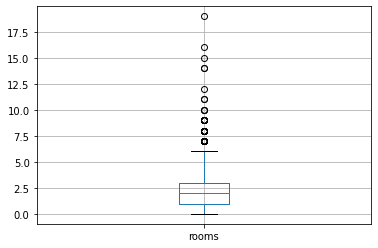

In [117]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('rooms')
plt.show()

In [118]:
wiskers('rooms')

(0, 6)

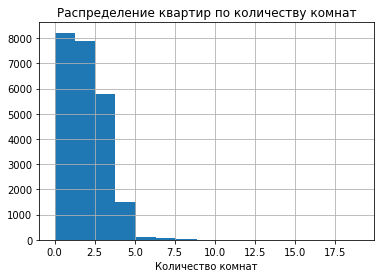

In [119]:
# построим гистограмму
data['rooms'].hist(bins=15)
plt.title('Распределение квартир по количеству комнат')
plt.xlabel('Количество комнат')
plt.show()

In [120]:
# посмотрим какие квартиры имеют 0 комнат:
data.query('rooms == 0')[['is_apartment', 'studio', 'open_plan']].mean()

is_apartment   0.00
studio         0.70
open_plan      0.30
dtype: float64

In [121]:
# сколько квартир с 0 комнат не имеют свободной планировки и не являются студиями
len(data.query('rooms == 0 and (studio == False and open_plan == False)'))

0

Квартиры в базе имеют от 0 до 19 компант. В среднем, на одну квартиру приходится 2 комнаты, медианная квартира также имеет 2 комнаты.

Большинство квартир имеет от 0 до 6 комнат. Все квартиры с 0 комнат, являются квартирами со свободной планировкой или студиями.

График имеет вид распределения Пуассона, аномалий не заметно.

##### Высота потолков

In [122]:
# изучим статистику по колонке
data['ceiling_height'].describe()

count   23609.00
mean        2.70
std         0.23
min         2.50
25%         2.60
50%         2.65
75%         2.70
max         8.30
Name: ceiling_height, dtype: float64

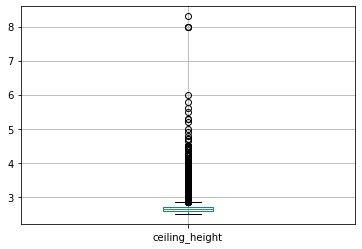

In [123]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('ceiling_height')
plt.show()

In [124]:
wiskers('ceiling_height')

(2.5, 2.85)

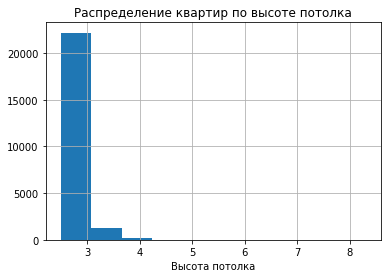

In [125]:
# построим гистограмму
data['ceiling_height'].hist()
plt.title('Распределение квартир по высоте потолка')
plt.xlabel('Высота потолка')
plt.show()

Квартиры в базе имеют высоту потолка 2.5 до 8 м (аномальные значения были исключены на этапе предобработки).
Средняя квартира имеет высоту потолка 2.70м., медианная - 2.65м.

Большинство квартир имеет высоту потолка от 2.5 до 2.85 м. 

Высокие потолки могут быть в квартирах с несколькими этажами или в частных домах.

График имеет вид распределения Пуассона, аномалий не заметно.

##### Тип этажа квартиры («первый», «последний», «другой»)

In [126]:
# изучим статистику по колонке
data['floor_type'].value_counts()

другой       17306
последний     3401
первый        2902
Name: floor_type, dtype: int64

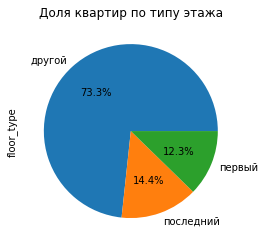

In [127]:
data['floor_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля квартир по типу этажа')
plt.show()

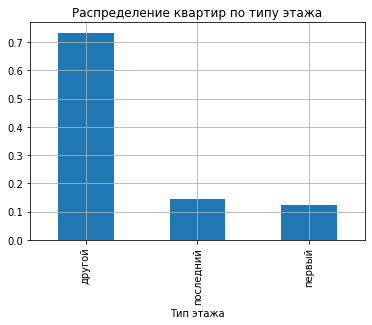

In [128]:
#доля квартир по типа этажей
data['floor_type'].value_counts(normalize=True).plot(kind='bar', grid=True)
plt.title('Распределение квартир по типу этажа')
plt.xlabel('Тип этажа')
plt.show()

Количество квартир на первом и последнем этажал примерно одинаковое. 73% квартир находятся а промежуточных этажах, аномалий не заметно.

##### Общее количество этажей в доме

In [129]:
# изучим статистику по колонке
data['floors_total'].describe()

count   23609.00
mean       10.68
std         6.60
min         1.00
25%         5.00
50%         9.00
75%        16.00
max        60.00
Name: floors_total, dtype: float64

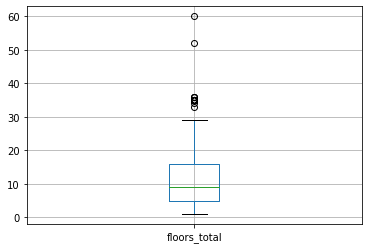

In [130]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('floors_total')
plt.show()

In [131]:
wiskers('floors_total')

(1, 29)

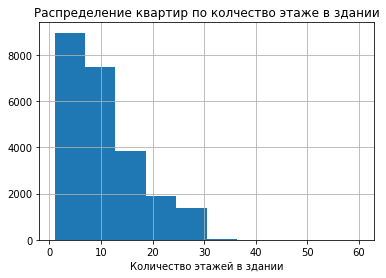

In [132]:
# построим гистограмму
data['floors_total'].hist()
plt.title('Распределение квартир по колчество этаже в здании')
plt.xlabel('Количество этажей в здании')
plt.show()

В выборку попали дома с количеством этаже от 1 до 60. В среднем дома имеют 11 этажей, медианный дом имеет 9 этажей.

Большинство домов имеют от 1 до 29 этажей.

Самое высокое здание в петербурге (по информации в интернете) содержит 87 этажей, так что значения находятся в пределах нормы.

График имеет вид распределения Пуассона, аномалий не заметно.

##### Расстояние до центра города в метрах

In [133]:
# изучим статистику по колонке
data['city_centers_nearest'].describe()

count   18129.00
mean    14186.29
std      8607.51
min       181.00
25%      9234.00
50%     13095.00
75%     16293.00
max     65968.00
Name: city_centers_nearest, dtype: float64

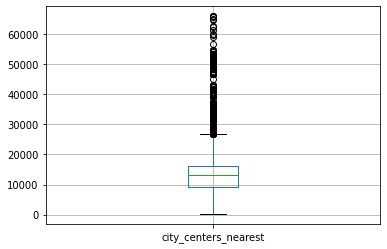

In [134]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('city_centers_nearest')
plt.show()

In [135]:
wiskers('city_centers_nearest')

(181.0, 26872.0)

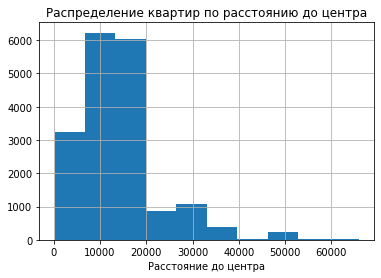

In [136]:
# построим гистограмму
data['city_centers_nearest'].hist()
plt.title('Распределение квартир по расстоянию до центра')
plt.xlabel('Расстояние до центра')
plt.show()

В выборку попали дома на расстоянии от 181 до 65968 м. В среднем дома находятся на удалении 17426 м. от центра Санкт-Петербурга, медианное значение - 14975 м.

Большинство домов находятся в пределах от 181 до 54926 метров от центра города.

На гистограмме выше заметно, что на расстоянии около 30000м наблюдается пик значений. Это пик приходится на квартиры, которые находятся за пределами Санкт-Петербурга. Одна из-за того, что на этапе предобработки по большинству таких квартир дистанция была неизвестна и замещена медианным значением, то информация о дистанциях квартир за пределами города распределена не равномерно.  

Других аномалий на графике не заметно.

##### Расстояние до ближайшего парка

In [137]:
data['parks_nearest'].isna().sum() / len(data)

0.6590706933796433

65.9% квартир, оставшихся в выборке не имеют информации о расстонии до ближайшего парка.

По квартирам с информацией посмотрим статистику.

In [138]:
# изучим статистику по тем квартирам, у которых есть инфа по паркам
data['parks_nearest'].describe()

count   8049.00
mean     490.83
std      342.79
min        1.00
25%      288.00
50%      454.00
75%      612.00
max     3190.00
Name: parks_nearest, dtype: float64

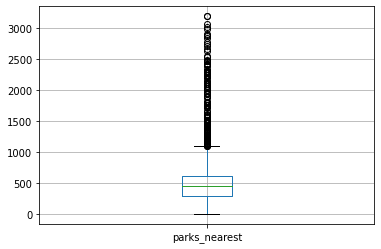

In [139]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('parks_nearest')
plt.show()

In [140]:
wiskers('parks_nearest')

(1.0, 1098.0)

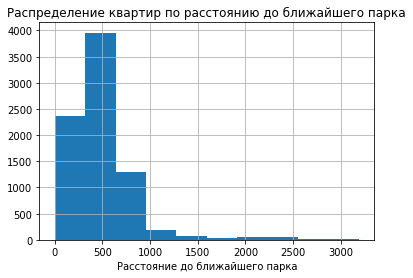

In [141]:
# построим гистограмму
data['parks_nearest'].hist()
plt.title('Распределение квартир по расстоянию до ближайшего парка')
plt.xlabel('Расстояние до ближайшего парка')
plt.show()

Приблизительно 66% квартир не имеет информации о ближайшем парке, скорей всего парков в ближайшей округе нету.

Остальные квартиры находятся на расстоянии от 1 до 3190 м. до ближайшего парка.

График по остальным домам имеет вид распределения Пуассона, аномалий не заметно.

#### Скорость продажи квартир

Посмотрим статистику по срокам продажи.

In [142]:
data['days_exposition'].describe()

count   20440.00
mean      181.05
std       219.96
min         1.00
25%        45.00
50%        95.00
75%       232.00
max      1580.00
Name: days_exposition, dtype: float64

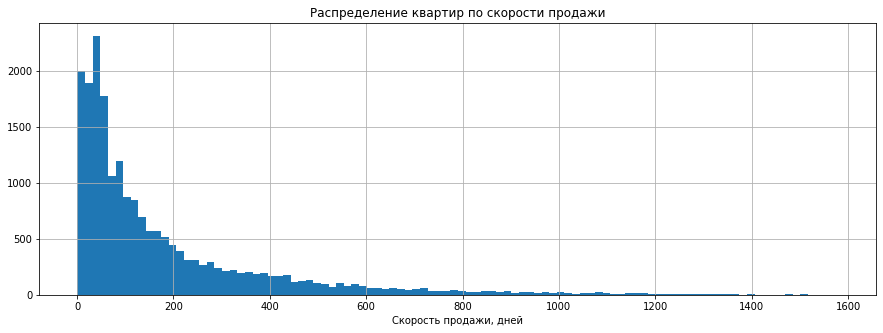

In [143]:
data['days_exposition'].hist(bins=100, figsize=(15,5))
plt.title('Распределение квартир по скорости продажи')
plt.xlabel('Скорость продажи, дней')
plt.show()

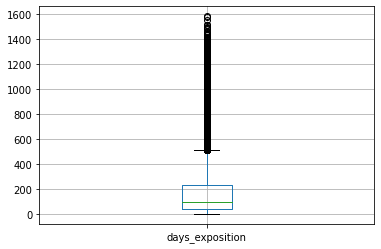

In [144]:
# Визуализируем статистику на диаграмме размаха 
data.boxplot('days_exposition')
plt.show()

In [145]:
wiskers('days_exposition')

(1.0, 512.0)

Обычно продажа занимает в среднем около 181 день. 

Продажи, которые занимают менее 45 дней, можно считать быстрыми, в то время как продажи, которые занимают более 232 дней, можно считать долгими.

Сделки которые совершаются посде 512 дней очень редкие. При это в выборке присутствуют сделки закрытые по истечении 1580 дней, что очень долго!

#### Факторы влияющие на общую (полную) стоимость объекта.

Изучим, влияют ли на полную стоимость квартиры следующие факторы:

- общая площадь;
- жилая площадь;
- площадь кухни;
- количество комнат;
- этаж, на котором расположена квартира (первый, последний, другой);
- дата размещения (день недели, месяц, год).

In [146]:
data.corr()['last_price'].sort_values()

city_center_nearest_km   -0.21
city_centers_nearest     -0.21
ponds_nearest            -0.08
year                     -0.04
airports_nearest         -0.03
studio                   -0.03
parks_nearest            -0.02
open_plan                -0.01
floors_total             -0.01
weekday                   0.00
month                     0.00
balcony                   0.01
floor                     0.03
is_apartment              0.03
days_exposition           0.08
total_images              0.10
parks_around3000          0.20
ponds_around3000          0.21
ceiling_height            0.28
rooms                     0.36
kitchen_area              0.44
living_area               0.54
total_area                0.65
price_per_meter           0.74
last_price                1.00
Name: last_price, dtype: float64

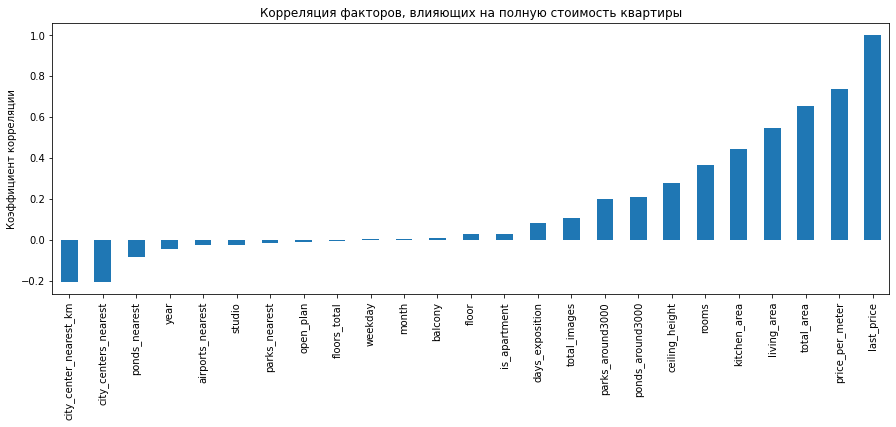

In [147]:
# пострим график корреляции last_price от других числовых параметров таблицы data
data.corr()['last_price'].sort_values().plot(kind='bar', figsize=(15,5))
plt.title('Корреляция факторов, влияющих на полную стоимость квартиры')
plt.ylabel('Коэффициент корреляции')
plt.show()

Наибольшее влияние на стоимость квартиры оказывает `общая площадь квартиры`, `жилая площадь`, `площадь кухни` и `количество комнат` в порядке убывания (умеренная положительная связь).

Влияние остальных параметров на стоимость недвижимости слабое или вовсе отсуствует.

Посмотрим более детельно зависимости в разбивке по каждому фактору отдельно.

##### Площадь

In [148]:
# создадим функции для рисования графика scatter по двум параметрам
def scatter(column1, column2, df=data):
    df[[column1, column2]].plot(kind='scatter', x=column1, y=column2, figsize=(10,5), grid=True, title=f'Зависимость {column2} от {column1}')

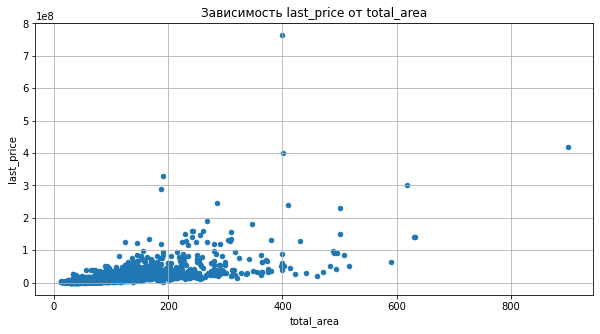

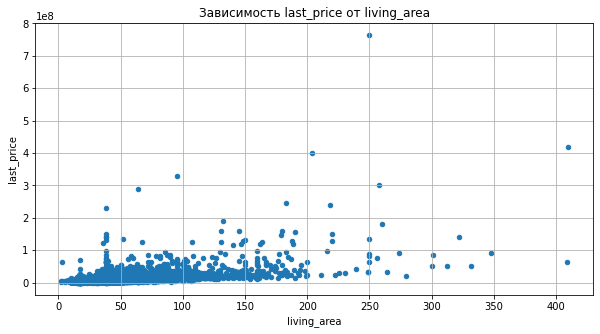

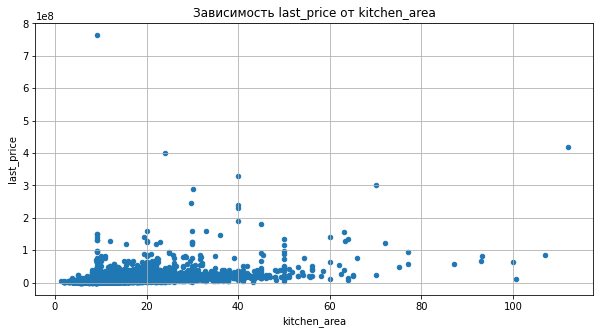

In [149]:
# нарисуем графики зависимости last_price от указанных выше факторов
for item in ['total_area', 'living_area', 'kitchen_area']:
    scatter(item, 'last_price')

Чем больше площадь квартиры (общая, жилая, кухня), тем как правило больше общая стоимость квартиры.

##### Количество комнат

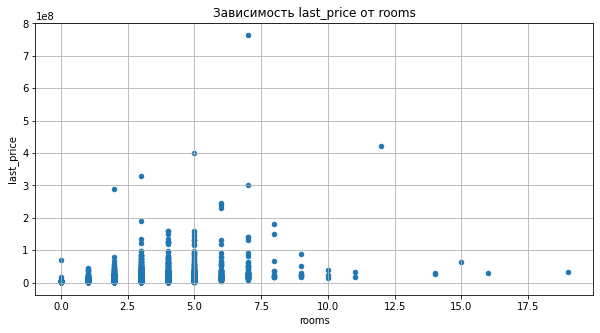

In [150]:
scatter('rooms', 'last_price')

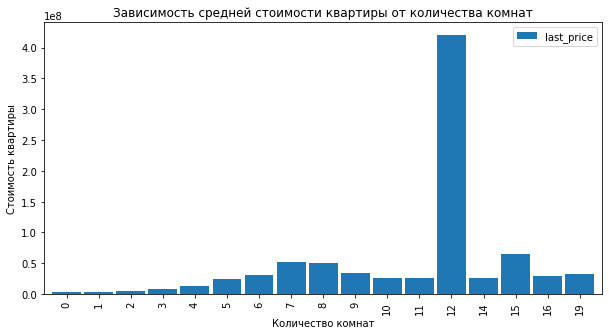

In [151]:
data.pivot_table(index='rooms', values='last_price', aggfunc='mean').plot(kind='bar', width=0.9, figsize=(10,5))
plt.title('Зависимость средней стоимости квартиры от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Стоимость квартиры')
plt.show()

Стоимость квартиры растет по мере увеличения количества комнат. 
Больше всего стоят квартиры с 7 и 8 комнатами, после чего стоимость квартир несколько снижается.

Квартир с более 10 компанатами единицы, поэтому данные по ним не очень репрезентативны.

##### Этаж квартиры

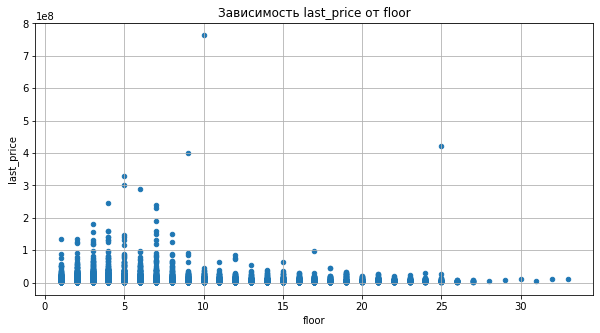

In [152]:
scatter('floor', 'last_price')

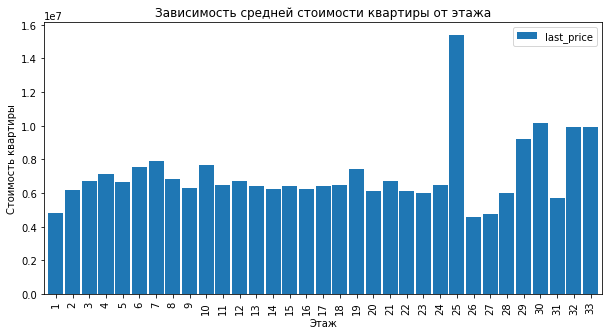

In [153]:
data.pivot_table(index='floor', values='last_price', aggfunc='mean').plot(kind='bar', width=0.9, figsize=(10,5))
plt.title('Зависимость средней стоимости квартиры от этажа')
plt.xlabel('Этаж')
plt.ylabel('Стоимость квартиры')
plt.show()

In [154]:
# определим функцию для создания bar
def bar(column1, column2, df=data, aggfunc='mean'):
    df.pivot_table(index=column1, values=column2, aggfunc=aggfunc).plot(kind='bar', width=0.9, figsize=(10,5), grid=True)
    plt.title(f'Зависимость {column2} от {column1}')

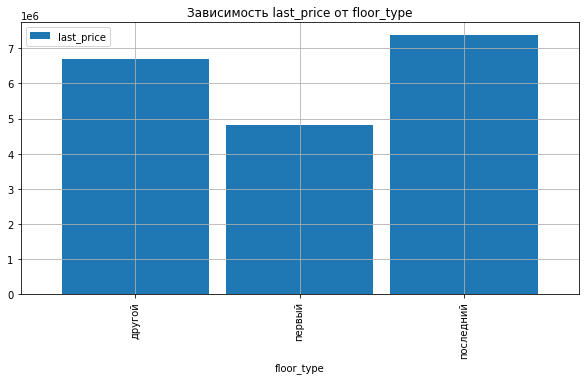

In [155]:
# посмотрим среднее значение last_price в зависимости от типа этажа
bar('floor_type', 'last_price')

Стоимость квартиры практически не зависит от этажа, на котором она находится.

При этом квартиры со стоимостью >200 млн расположены выше 1го этажа.

Квартиры на первом этаже в среднем стоят дешевле, чем квартиры на всех других этажах. Дороже всего стоят квартиры на последних этажах зданий.

##### Дата размещения объявления (день недели, месяц, год)

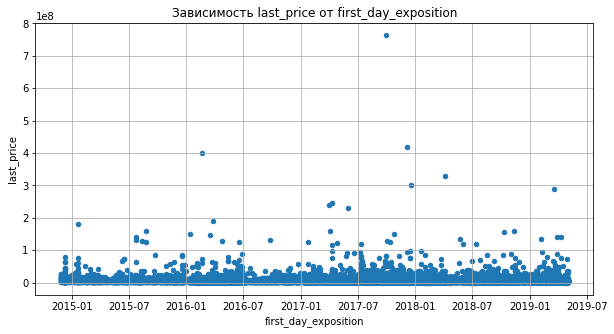

In [156]:
scatter('first_day_exposition', 'last_price')

In [157]:
# определим функцию для создания bar
def bar(column1, column2, df=data, aggfunc='mean'):
    df.pivot_table(index=column1, values=column2, aggfunc=aggfunc).plot(kind='bar', width=0.9, figsize=(10,5), grid=True)

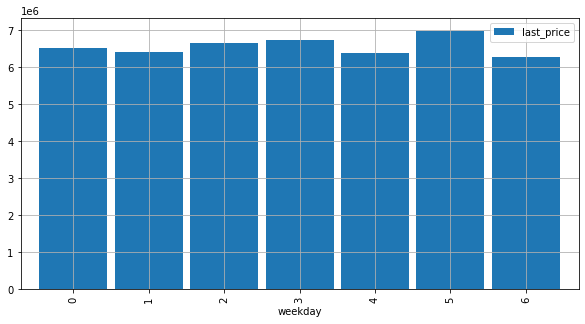

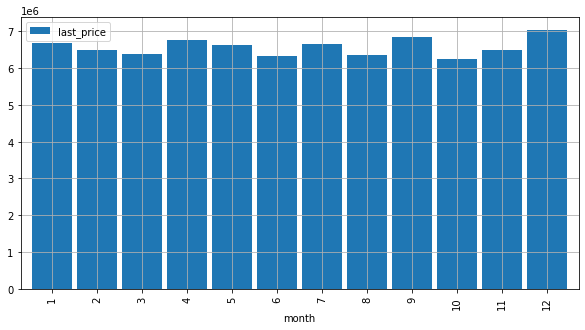

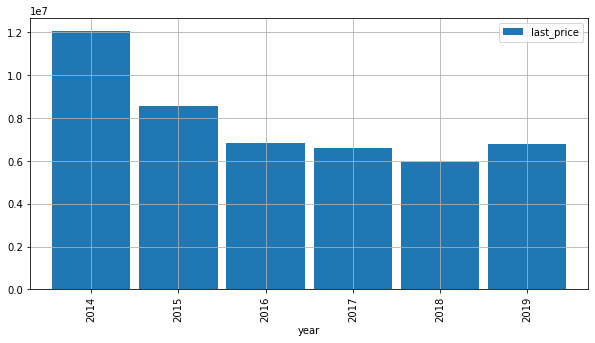

In [158]:
# нарисуем графики зависимости last_price от указанных выше факторов
for item in ['weekday', 'month', 'year']:
    bar(item, 'last_price')


- Средняя цена квартиры выше всего в сделках, совершенных в субботу и ниже всего в воскресенье.
- Дороже всего квартиры продавались в декабре, а дешевле всего в октябре.
- Общая средняя стоимость квартир в период с 2014 по 2018 год снижалась, в 2019 году цену немного выросли и вернулись к уровню 2016 года.

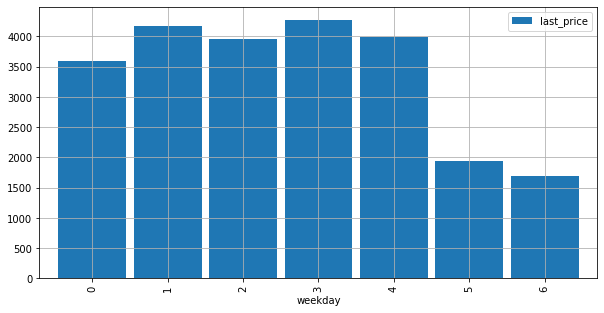

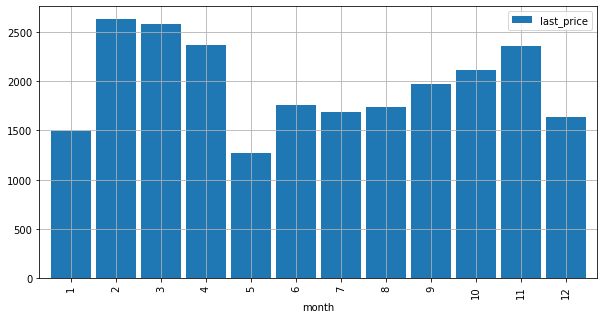

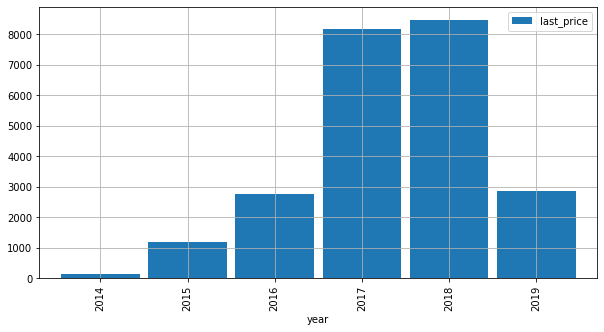

In [159]:
# нарисуем графики зависимости last_price от количества сделок
for item in ['weekday', 'month', 'year']:
    bar(item, 'last_price', aggfunc='count')

In [160]:
data.query('year == 2019')['month'].max()

5

- Больше всего сделок совершается в будние дни, по выходным количество сделок падает в примерно 2 раза.
- Больше всего сделок совершается с февраля по апрель, меньше всего в мае, декабре и январе.
- Количество сделок с 2014 года увеличилось на порядок, и достигло максимума в 2017 и 2018 гг. За 2019 год данные неполные и ограничиваются маем месяцем.

#### Cредняя цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений

In [161]:
average_price_top10 = (data
    .pivot_table(index='locality_name', values='price_per_meter', aggfunc=['count', 'mean'])
    .sort_values(by=('count', 'price_per_meter'), ascending=False)
    .head(10)
)

average_price_top10.columns = ['Количество объявлений', 'Средняя цена квадратного метра']
average_price_top10 = average_price_top10.join(
    data.groupby('locality_name')['city_centers_nearest']
    .mean()
    .rename('Среднее расстояние до центра')
)

average_price_top10.style.highlight_max(subset='Средняя цена квадратного метра', color='lightgreen') \
    .highlight_min(subset='Средняя цена квадратного метра', color='lightcoral')

,Количество объявлений,Средняя цена квадратного метра,Среднее расстояние до центра
locality_name,,,
Санкт-Петербург,15719,114822.484366,11594.475284
Мурино,590,86087.512017,21888.000000
Кудрово,471,95326.179108,nan
Шушары,440,78677.364318,24243.387615
Всеволожск,397,68719.320378,nan
Пушкин,366,103147.825574,28761.747945
Колпино,337,75443.972849,32114.523810
Парголово,326,90205.423374,19920.785276
Гатчина,307,68746.146515,nan


In [162]:
average_price_top10.corr()

,Количество объявлений,Средняя цена квадратного метра,Среднее расстояние до центра
Количество объявлений,1.00,0.63,-0.79
Средняя цена квадратного метра,0.63,1.00,-0.65
Среднее расстояние до центра,-0.79,-0.65,1.00


Санкт-Петербург имеет самую высокую среднюю цену квадратного метра среди всех населённых пунктов в списке. Это объясняется высоким спросом на недвижимость в столице Северо-Западного региона России, а также её статусом крупного культурного и экономического центра.

Мурино, Кудрово и Шушары также находятся вблизи Санкт-Петербурга и имеют сравнительно высокую среднюю цену квадратного метра. Эти местности являются популярным выбором для тех, кто предпочитает более спокойную жизнь за пределами города, но при этом находится в непосредственной близости от его инфраструктуры.

Пушкин, Колпино и Парголово также расположены вблизи Санкт-Петербурга и имеют относительно высокую среднюю цену квадратного метра. Эти районы обладают исторической ценностью, а также хорошо развитой инфраструктурой и доступом к природным зонам, что делает их привлекательными для жизни.

Всеволожск, Гатчина и Выборг имеют более низкие средние цены квадратного метра по сравнению с предыдущими населёнными пунктами. Эти местности находятся на большем удалении от Санкт-Петербурга и могут быть более доступными с точки зрения цен на недвижимость. Они имеют свои преимущества, такие как просторная природа и более спокойная обстановка.

Общая тенденция показывает, что близость к Санкт-Петербургу и развитая инфраструктура являются факторами, влияющими на повышение средней цены квадратного метра. Также стоит учитывать и другие факторы, такие как доступность образовательных учреждений, транспортных коммуникаций, природных ресурсов и общей привлекательности местности для жизни.

#### Стоимость квартир в Санкт-Петербурге

Ранее мы посчитали расстояние до центра в километрах.

Теперь выделим квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислим их среднюю стоимость на разном удалении от центра. Учтем каждый километр расстояния, например, узнаем среднюю цену квартир в одном километре от центра, в двух и так далее. 

Опишишем, как стоимость объектов зависит от расстояния до центра города — построим график изменения средней цены для каждого километра от центра Петербурга.

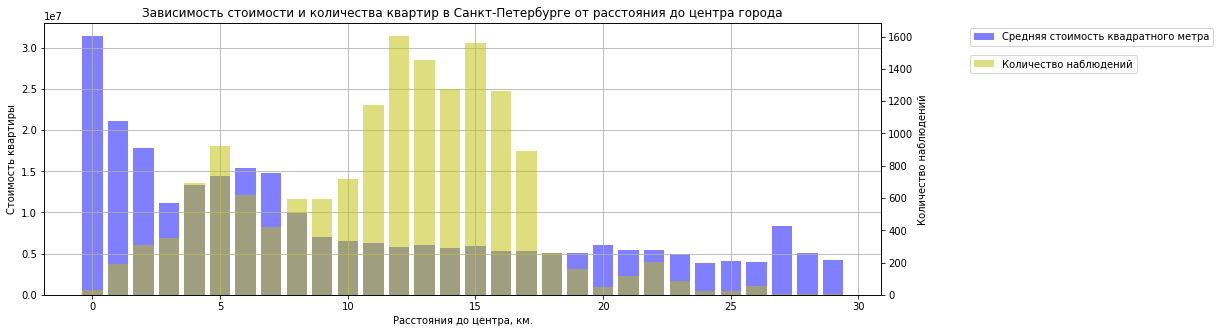

In [163]:
# Группировка данных
grouped_data = data[data['locality_name'] == 'Санкт-Петербург'].groupby('city_center_nearest_km')

# Средняя стоимость квадратного метра
mean_price = grouped_data['last_price'].mean().reset_index()

# Количество наблюдений
count_data = grouped_data.size().reset_index(name='count')

# Создание графика
fig, ax1 = plt.subplots(figsize=(15, 5))

# Первая ось (средняя стоимость квадратного метра)
ax1.bar(mean_price['city_center_nearest_km'], mean_price['last_price'], color='b', alpha=0.5)
ax1.set_xlabel('Расстояния до центра, км.')
ax1.set_ylabel('Стоимость квартиры')
ax1.set_title('Зависимость стоимости и количества квартир в Санкт-Петербурге от расстояния до центра города')
ax1.grid(True)

# Вторая ось (количество наблюдений)
ax2 = ax1.twinx()
ax2.bar(count_data['city_center_nearest_km'], count_data['count'], color='y', alpha=0.5)
ax2.set_ylabel('Количество наблюдений')

# Добавление легенды
ax1.legend(['Средняя стоимость квадратного метра'], loc='upper left', bbox_to_anchor=(1.1, 1))
ax2.legend(['Количество наблюдений'], loc='upper left', bbox_to_anchor=(1.1, 0.9))


# Отображение графика
plt.show()

In [164]:
# посмотрим квартиры на 27 км от центре
data.query('locality_name == "Санкт-Петербург" and city_center_nearest_km == 27')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_legacy,price_per_meter,weekday,month,year,floor_type,city_center_nearest_km
744,13,14350000.00,74.00,2017-11-28,2,3.13,5,30.00,3,False,False,False,25.00,0,Санкт-Петербург,23888.00,27313.00,1,1496.00,0,NaN,128.00,Санкт-Петербург,193918.92,1,11,2017,другой,27
5937,6,2250000.00,32.00,2018-02-27,1,2.65,2,16.50,2,False,False,False,7.00,0,Санкт-Петербург,24006.00,27431.00,0,NaN,0,NaN,178.00,Санкт-Петербург,70312.50,1,2,2018,последний,27


На графике показано, как цена квартиры изменяется в зависимости от расстояния до центра Санкт-Петербурга. На оси абсцисс (X) отложены расстояния до центра города (в километрах), а на оси ординат (Y) —  стоимость квартиры (в рублях) и количество квартир.

Как видно из графика, самая высокая цена наблюдается в центре города (0 км), что вполне ожидаемо, так как центр Санкт-Петербурга является самым престижным и дорогим районом.

В первые несколько километров от центра (до 3 км) цена за квадратный метр резко падает. Это указывает на значительное снижение цен при небольшом удалении от центральных районов.

Пик на расстоянии 5 км от центра города как по количеству квартир, так и по их стоимости, может быть связан с несколькими факторами:
- на этом расстоянии могут находиться как жилые, так и коммерческие объекты, которые более доступны по цене, что приводит к большему количеству квартир и более низкой средней стоимости. 
- в этой области может быть высокий спрос на недвижимость из-за близости к центру города, что приводит к большему количеству доступных для продажи или аренды квартир. Кроме того, здесь может быть высокая концентрация различных объектов инфраструктуры, таких как транспорт, школы и торговые центры, что делает это место более привлекательным для потенциальных покупателей и арендаторов. 

Начиная примерно с 9 км, цены показывают тенденцию к стабилизации, хотя и продолжают снижаться, но уже не так резко. Наблюдаются незначительные колебания, что может быть связано с различием в престижности и инфраструктуре районов на этом расстоянии.

На расстоянии 27 км наблюдается резкий всплеск цен, что может быть обусловлено наличием каких-то элитных объектов или специфических районов, которые востребованы несмотря на удаленность от центра. В то же время в выборку попало всего 2 значения, что может исказить результаты для этого расстояния. 

***Выводы***

- Стоимость жилья в Санкт-Петербурге резко снижается при удалении от центра города, что подтверждает общую тенденцию более высоких цен в центральных районах.
- На расстоянии 5 км от центра наблюдается небольшой пик как по количеству квартир, так и по их стоимости. Это может быть связано с доступностью и спросом на жилье, а также с высокой концентрацией различных объектов инфраструктуры в этой области.
- Аномальные пики на большом удалении от города могут указывать на специфические районы или элитные объекты, а также погрешности ввиду небольшого количества квартир в выборке для дальних расстояний, которые влияют на стоимость жилья на данном расстоянии.

#### Дополнительные наблюдения

Посмотрим еще раз на матрицу корреляции цифровых значений. 

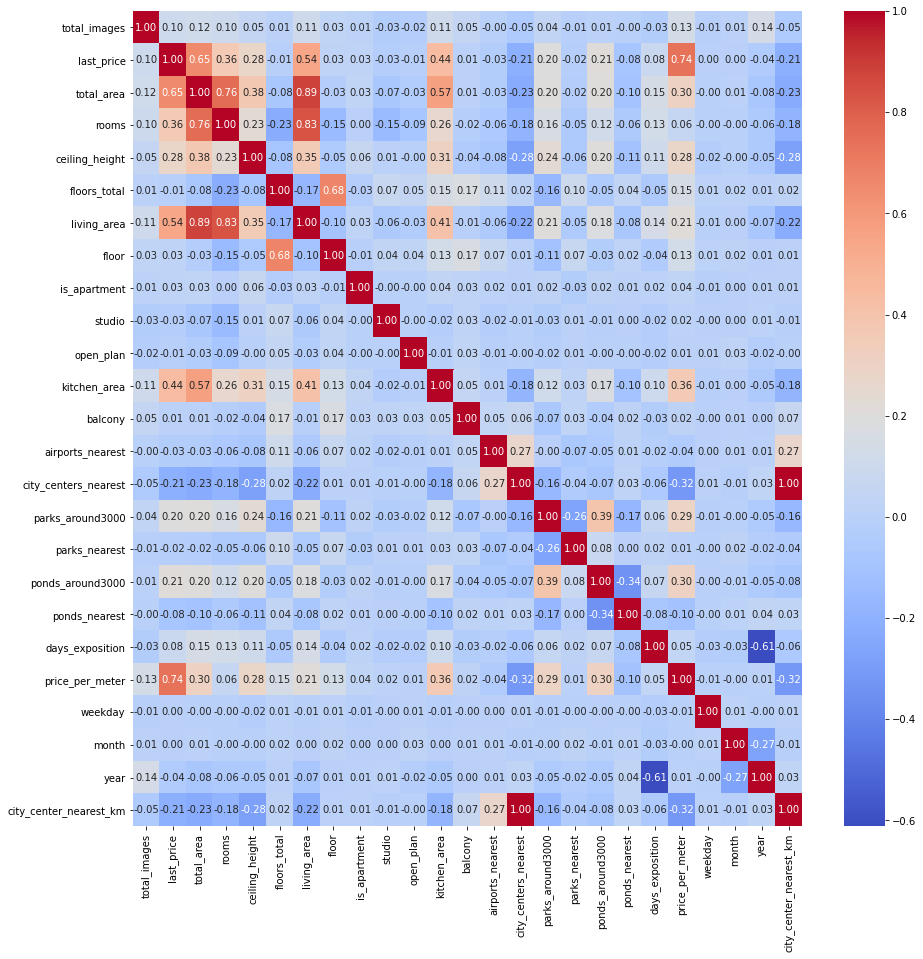

In [165]:
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt='.2f')
plt.show()

1. На тепловой карте заметно, что между `last_price`, `total_area`, `living_area`, `kitchen_area`, `ceiling_height` и `rooms` заметна Достаточно сильная взаимная корреляция.
2. Обратим внимание, на странную обратную зависимость между `year` и `days_exposition`. Посмотрим на эти данные подробнее

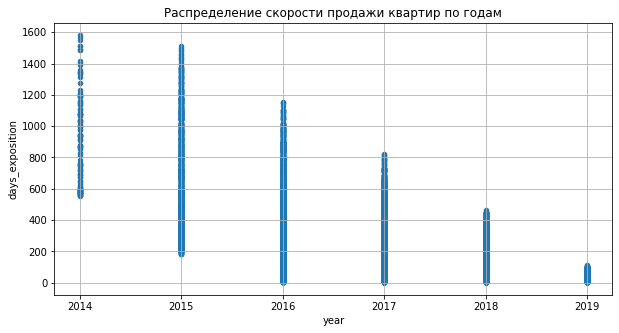

In [166]:
data[['year', 'days_exposition']].plot(kind='scatter', x='year', y='days_exposition', figsize=(10,5), grid=True)
plt.title('Распределение скорости продажи квартир по годам')
plt.show()

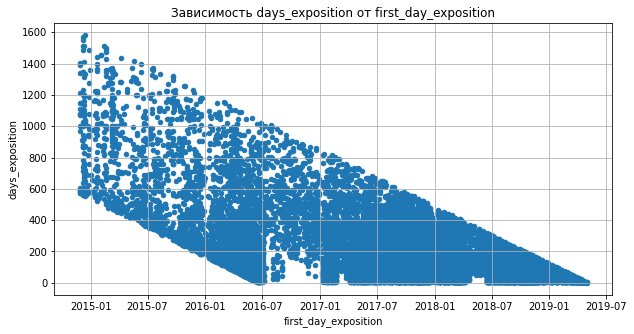

In [167]:
scatter('first_day_exposition', 'days_exposition')

In [168]:
data[['year', 'days_exposition']].describe()

,year,days_exposition
count,23609.00,20440.00
mean,2017.37,181.05
std,1.04,219.96
min,2014.00,1.00
25%,2017.00,45.00
50%,2017.00,95.00
75%,2018.00,232.00
max,2019.00,1580.00


На графике заметны серьезные аномалии в данных:

- В 2015-2016 гг. сделки закрывались с очень длинными сроками. Отсутствуют данные по быстрым продажам квартир. 
- с июля 2016 по декабрь 2016 года наблюдается странный паттер распределения данных со сроками заявок до 200 дней, локальные неоднородности также заметны весной 2017 года и летом 2018 года.

Попробуем разобраться в причинах.

***Гиппотеза.*** Проверим, возможно данные были каким-то образом удалены или изменены во время подготовки данных

In [169]:
# проверим, может эти данные были каким-то образом удалены во время подготовки данных
# загрузим первоначальный датасет в новую переменную и сохраним в новую переменную data_clear
data_clear = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
# приведем даты в нужный формат
data_clear['first_day_exposition'] = pd.to_datetime(data_clear['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

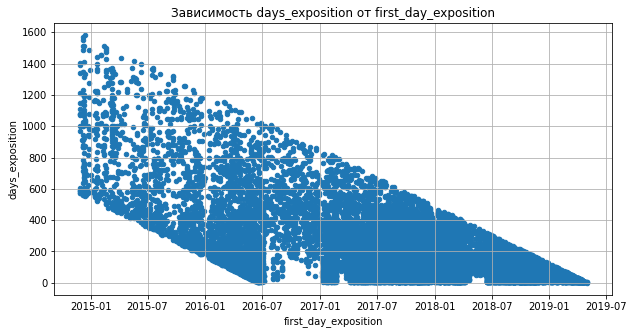

In [170]:
scatter('first_day_exposition', 'days_exposition', df=data_clear)

Данные имеют точно такой же вид, гиппотеза не подтвердилась. Предобработка тут ни причем.

Приблизим масштаб графика в периоды аномальной активности.

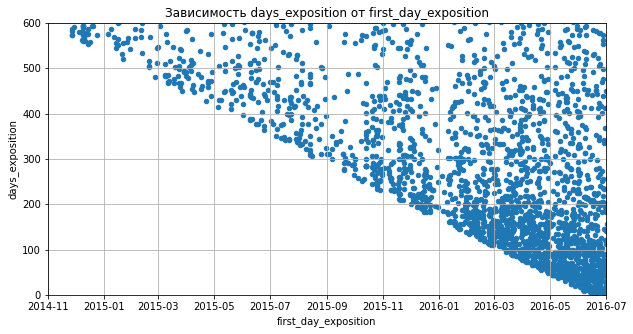

In [171]:
# посмотрим данные до 1 июля 2016 года и количество дней до 600
scatter('first_day_exposition', 'days_exposition')
plt.xlim(pd.Timestamp('2014-11-01'), pd.Timestamp('2016-07-01'))
plt.ylim(0, 600)
plt.show()

Клинообразная форма графика в нижней части говорит о том, что заявления опубликованные до 1 июля 2016 года попали в выборку только если они были исполнены после 1 июля 2016 года либо же мгновенно день в день. Возможна серьезная техническая ошибка в работе платформы в указанный период, либо ошибка в процессе сбора данных. Без уточнения дополнительной информации от разработчиков системы сложно установить причины такой аномалии.

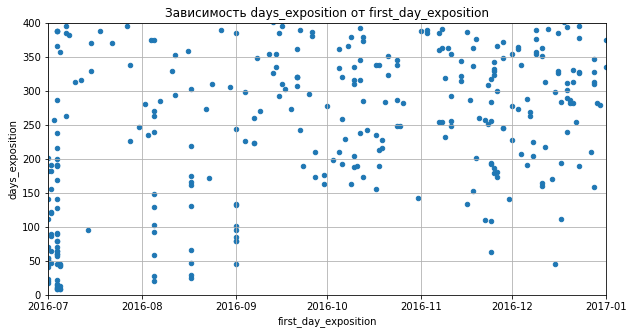

In [172]:
# посмотрим данные за второе полугодие 2016 г. и количеством дней до 400
scatter('first_day_exposition', 'days_exposition')
plt.xlim(pd.Timestamp('2016-07-01'), pd.Timestamp('2017-01-01'))
plt.ylim(0, 400)
plt.show()

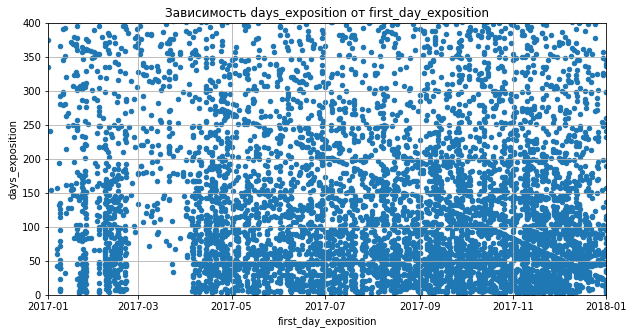

In [173]:
# посмотрим данные за 2017 г. и количеством дней до 400
scatter('first_day_exposition', 'days_exposition')
plt.xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2018-01-01'))
plt.ylim(0, 400)
plt.show()

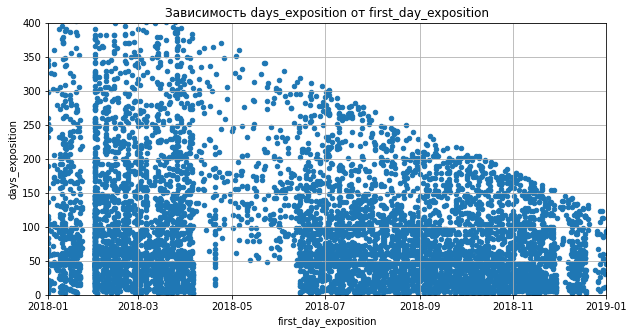

In [174]:
# посмотрим данные за 2018 г. и количеством дней до 400
scatter('first_day_exposition', 'days_exposition')
plt.xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2019-01-01'))
plt.ylim(0, 400)
plt.show()

Во втором полугодии 2017 г. наблюдается странная активность пользователей, в отдельные дни проходили заявки с разными сроками (видны четко выраженные столбцы в нижней части графика), в то время как большую часть времени краткосрочного исполнения заявок не было. Аналогичные аномалии также наблюдались в марте-апреле 2017 г. и апреле-июне 2018 г.

#### Вывод

На основе проведенного исследовательского анализа данных, можно сделать следующие выводы:

**1.  Параметры объектов и аномальные значения**
- Цена объекта: было найдено 1 аномально низкое значение стоимости объекта. Вероятно оно указано в тыс. рублей, значение было домножено на 1000.
- Частота с которой распределены все остальные параметры имеет вид распределения Пуассоана, сереьзных анонмалий в данных на данном этапе выявлено не было.
- Типичная квартира, продающаяся на сайте, представляет собой квартиру:
 - общей площадью 60м2, из которых: 34м2 - жилая площадь, 10м2 - кухня.
 - стоимость квартиры составляет около 6,5 млн. рублей, при стоимости квадратного метра около 100 тыс. рублей.
 - квартира имеет 2 комнаты и высоту потолков около 2,70 см.
 - располагается в многоэтажном здании на средних этажах.
 - находится в пределах 11-29км от центра города и не имеет парков/водоемов в ближайшем окружении.
 
**2. Скорость продажи квартир**
- Обычная продажа занимает в среднем около 181 дней.
- Продажи, которые занимают менее 45 дней, можно считать быстрыми, в то время как продажи, которые занимают более 232 дней, можно считать долгими.

**3. Факторы влияющие на общую (полную) стоимость объекта:**
- Наибольшее влияние на стоимость квартиры оказывают: общая площадь квартиры, жилая площадь, площадь кухни и количество комнат (перечислены в порядке убывания).
- Чем больше площадь квартиры (общая, жилая, кухня), тем как правило больше общая стоимость квартиры.
- Стоимость квартиры растет по мере увеличения количества комнат. Больше всего стоят квартиры с 7 и 8 комнатами, после чего стоимость квартир несколько снижается. Квартир с более 10 компанатами единицы, поэтому данные по ним не очень репрезентативны.
- Стоимость квартиры практически не зависит от этажа, на котором она находится. Однако дешевле всего стоят квартиры на первом этаже, дороже всего - квартиры на последних этажах зданий.
- Средняя цена квартиры выше всего в сделках, совершенных в субботу и ниже всего в воскресенье. При этом больше всего сделок совершается в будние дни, а по выходным ежедневный объем сделок сокращается примерно в 2 раза.
- Дороже всего квартиры продавались в декабре, а дешевле всего в октябре. В целом, зависимость цены от дня недели и месяца года несущественная.
- Общая средняя стоимость квартир в период с 2014 по 2018 год снижалась, в 2019 году цену немного выросли и вернулись к уровню 2016 года. При этом количество сделок с 2014 года увеличилось на порядок, и достигло максимума в 2017 и 2018 гг. За 2019 год данные неполные и ограничиваются маем месяцем.

**4. Cредняя цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений**
- Больше всего объявлений о продаже квартир в Санкт-Петербурге, что в 38 раз больше чем объявлений в следующем по количеству объявлений городе: "Шушары".
- В ТОП10 самые дорогой квадратный метр также приходится на Санкт-Петербург (около 115 тыс. рублей), а самый недорогой в н.п. Выборг(около 58 тыс. рублей).
- Общая тенденция показывает, что близость к Санкт-Петербургу и развитая инфраструктура являются факторами, влияющими на повышение средней цены квадратного метра. Также стоит учитывать и другие факторы, такие как доступность образовательных учреждений, транспортных коммуникаций, природных ресурсов и общей привлекательности местности для жизни.

**5.  Стоимость квартир в Санкт-Петербурге**

- Стоимость жилья в Санкт-Петербурге резко снижается при удалении от центра города, что подтверждает общую тенденцию более высоких цен в центральных районах.
- На расстоянии 5 км от центра наблюдается небольшой пик как по количеству квартир, так и по их стоимости. Это может быть связано с доступностью и спросом на жилье, а также с высокой концентрацией различных объектов инфраструктуры в этой области.
- Аномальные пики и падения могут указывать на специфические районы или элитные объекты, а на удалении от центра также сказывается погрешность ввиду небольшого количества квартир в выборке на таком расстоянии.

**6. Дополнительные наблюдения**

- Между last_price, total_area, living_area, kitchen_area, ceiling_height и rooms заметна умеренная взаимная корреляция.
- На графике заметна серьезная аномалии в данных по количеству дней размещения объявлений (от публикации до снятия) в период с 2014 по 2016 г.
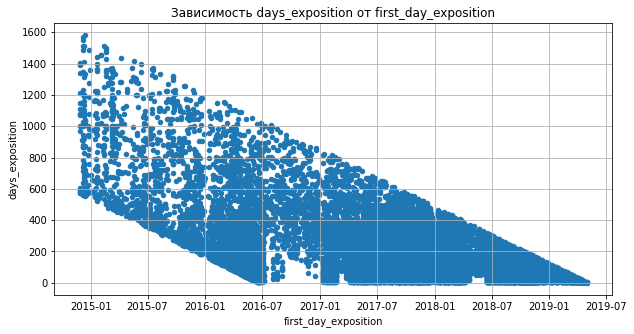

- в 2014-2016 гг. сделки закрывались с очень длинными сроками. Отсутствуют данные с короткими значениями days_exposition.
- с июля 2016 по декабрь 2016 года наблюдается странный паттерн распределения данных со сроками заявок до 200 дней. В отдельные дни проходили заявки с разными сроками (видны четко выраженные столбцы в нижней части графика), в то время как большую часть времени краткосрочного исполнения заявок не было.
- клинообразная форма графика в нижней части говорит о том, что заявления опубликованные до 1 июля 2016 года попали в выборку только если они были исполнены после 1 июля 2016 года. Возможна серьезная техническая ошибка в работе платформы в указанный период, либо ошибка в процессе сбора данных. Для установления причин аномалии рекомендуется получить дополнительную информацию от разработчиков системы о работе системы в указанный период и методологии сбора данных.


### Напишите общий вывод

**1. Предобработка данных**

В процессе предобработки данных были выполнены следующие шаги:

1. Обработаны и устранены дубликаты, включая неявные дубликаты в названиях населенных пунктов.
2. Заполнены пропущенные значения: для некоторых колонок использованы медианные значения, логические допущения или маркерные значения, при этом часть данных с пропусками была удалена.
3. Проведена корректировка аномальных значений, таких как высота потолков.
4. Изменены типы данных для соответствия нужным форматам.
5. Добавлены новые колонки для улучшения анализа, такие как `price_per_meter`, `weekday`, `month`, `year`, `floor_type`, и `city_center_nearest_km`.

**2. Выявленные зависимости цены недвижимости от других факторов**

Анализ показал, что на стоимость квартиры наибольшее влияние оказывают следующие параметры:

- Общая площадь, жилая площадь и площадь кухни квартиры: чем больше площадь, тем выше стоимость (зависимость умеренная положительная).
- Количество комнат: стоимость увеличивается с увеличением числа комнат до 7-8, после чего наблюдается снижение.
- Этажность: стоимость практически не зависит от этажа. Однако дешевле всего стоят квартиры на первом этаже, дороже всего - квартиры на последних этажах зданий.
- День недели: средняя цена выше всего в субботу и ниже всего в воскресенье.
- Месяц года: самые высокие цены зафиксированы в декабре, самые низкие — в октябре.
- Удаленность от центра: стоимость резко снижается при удалении от центра. На расстоянии 5 км от центра наблюдается небольшой пик как по количеству квартир, так и по их стоимости. Это может быть связано с доступностью и спросом на жилье, а также с высокой концентрацией различных объектов инфраструктуры в этой области.

**3. Описание типичной квартиры**

Типичная квартира, продающаяся в Санкт-Петербурге и соседних населенных пунктах, имеет следующие характеристики:

- Общая площадь: около 60 м², из которых 34 м² жилая площадь и 10 м² площадь кухни.
- Стоимость: около 6.5 млн рублей, при цене за квадратный метр около 100 тыс. рублей.
- Количество комнат: 2 комнаты.
- Высота потолков: около 2,70 м.
- Расположение: в многоэтажном здании на среднем этаже.
- Удаленность от центра: в пределах 11-29 км от центра города.
- Наличие парков и водоемов: отсутствуют в ближайшем окружении.

**4. Рекомендации заказчику**

- Улучшение качества данных: провести дополнительную проверку и корректировку данных, особенно в отношении расстояния до ближайших объектов.
- Анализ сезонности: учитывать сезонные колебания цен при планировании продаж и маркетинговых кампаний.
- Дополнительное исследование аномалий: провести детальное исследование выявленных аномалий в данных, особенно в отношении количества дней размещения объявлений для периода 2014-2016 гг, возможна техническая ошибка в данных или подозрительная активность продавцов на сайте.